# Quantum Reservoir Computing — Mario 1-1 Level Generator

Reproducing *Ferreira et al., "Level Generation with Quantum Reservoir Computing"* (arXiv:2505.13287)

**Pipeline**
1. Mario 1-1 level → Encode into 30 column-wise features (202-step sequence)
2. 6-qubit quantum circuit (fixed reservoir)
3. Train FNN (cross-entropy loss)
4. Generate level with feedback loop
5. Pixel rendering with actual sprites

| Parameter | Value |
|---|---|
| N_FEATURES | 30 |
| Sequence Length | 202 |
| Qubits | 6 |
| Leaking rate α | 0.3 |
| Temperature τ | 1.0 (recommended) |

## 0. Install & Import

In [ ]:
!pip install qiskit qiskit-aer matplotlib numpy Pillow -q

import numpy as np
import matplotlib.pyplot as plt
import base64, io, random, json
from PIL import Image
from collections import Counter
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

DARK_BG = '#0d0d1a'
CYAN    = '#00f0ff'
RED     = '#ff4466'
GREEN   = '#39ff14'
YELLOW  = '#ffcc00'
simulator = AerSimulator()
print('Ready')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.3 MB/s eta 0:00:00
Ready


## 1. Mario 1-1 Level Data

**QRC Input**: 30 unique column features based on txt file, 202-step sequence
**Rendering**: Actual sprite images (multi-column objects like pipes are grouped into a single image)

Prevent broken sequence: Force correction if a non-right pipe feature is generated after a left pipe (`<`, `[`) is generated

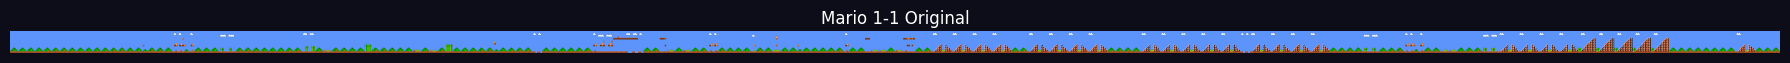

Sequence: 202 steps, 30 unique features
Top features: [(0, 109), (16, 13), (9, 10), (2, 9), (22, 6)]


In [ ]:
# ── Mario 1-1 Level Steps (202 steps, 30 features) ──────────────
N_FEATURES = 30

TRAINING = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 3, 4, 1, 2, 0, 0, 0, 5, 6, 0, 0, 0, 0, 0, 0, 0, 0, 7, 8, 0, 9, 0, 0, 0, 0, 10, 11, 0, 0, 0, 0, 0, 9, 0, 9, 0, 10, 11, 0, 0, 0, 0, 0, 12, 0, 0, 0, 0, 13, 13, 0, 0, 0, 0, 0, 0, 2, 14, 15, 16, 16, 17, 16, 16, 16, 18, 18, 13, 0, 0, 16, 16, 16, 4, 9, 0, 9, 0, 0, 2, 2, 0, 0, 0, 0, 19, 0, 0, 20, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 16, 16, 16, 9, 9, 0, 9, 16, 21, 4, 16, 0, 0, 22, 23, 24, 25, 0, 0, 25, 24, 23, 22, 0, 0, 0, 0, 22, 23, 24, 25, 25, 13, 13, 25, 24, 23, 22, 0, 0, 0, 0, 5, 6, 0, 0, 0, 2, 2, 1, 2, 0, 0, 9, 9, 0, 0, 0, 5, 6, 22, 23, 24, 25, 26, 27, 28, 29, 29, 0, 0, 0, 0, 0, 0, 0, 0, 22, 0, 0, 0]

# broken pair: (left_pipe_id, right_pipe_id)

PIPE_LEFT_IDS  = [5, 7, 10]
PIPE_RIGHT_IDS = [6, 8, 11]

# Real Sprite Image
_B64 = {"0": "iVBORw0KGgoAAAANSUhEUgAAAFAAAADQCAYAAACQoeZ1AAAEqklEQVR4nO3aL3LbWhhA8S8dw4CALqHACwjwAgoeMDA0yBIKDAIeDAwIKAjoAgIKDQoCsgCBt4CAt4iCQs34AT85km1Zso7+OPE5M50kkq6s+c21rqP04uYxXYU17tPQF/DeExAmIExAmIAwAWECwgSECQgTECYgTECYgDABYQLCBIQJCBMQJiBMQJiAMAFhAsIEhAkIExAmIExAmIAwAWECwgSECQgTECYgTECYgDABYQLCBIQJCBMQJiBMQJiAMAFhAsIEhAkIExAmIExAmIAwAWECwgSECQgTECYgTECYgDABYQLCBIQJCBMQJiBMQJiAMAFhAsIEhAkIExAmIExAmIAwAWECwgSECQgTECYgTECYgDABYQLCBIQJCBMQJiBMQJiAMAFhAsIEhAkIExAmIExAmIAwAWECwgSECQgTECYgTECYgDABYQLCBIQJCBMQJiBMQJiAMAFhAsIEhAkIExAmIExAmIAwAWECwgSECQgTECYgTECYgDABYQLCBIQJCBMQJiBMQJiAMAFhAsIEhAkIExAmIExAmIAwAWECwgSECQgTECYgTEDYaOgL2NfTt/2XdfOY9nwl1Z0MYAHtZ8kx87djTgVzcMANXAlaodwxGebQkIPeA5++jdYodfDyzWMzruzt3leDAW7wjm2+9XVgxEEAG+OVNSBi74Ct42UNhNgrIHrbziuPGgSxN8DWZt7Pra979veJ2AtgF/e8qv19IXYO2Nk9r6qeEDsFbPVt2+Q8PSB2BjjYzNuuY8ROAE8GL6tDxNYBTw4vqyPEVgFPFi+rA8TWAE8eL6tlxFYA3w1eVouIGPDd4WW1hIgA8SOprqp7/hYQL24e01WTga3gNZy5r3e728bZtibnnzd/st1oBg75tt2Hl21/vYt4HTc4KZiJR48a+p63/Ovt+9vxJCIiHl6TuB1PYnSVNL89/Fz/neXYmXjUDOz8eV5F98kbWvY1X/p7EumP3e21azATawP29jyvZg+vyeb72/Gk8HP6Y9L8/Eci1lpEMF7uD0Ck+/+NtmdfHi8i4m8wCTfVXFgqAVuZeS0BZqW/y4VGV0npvqOrgXgQcOgFY1/ZLJw9FxeUVmbdvioQS9/sp4y33ey5+HOrmBWr895F5L3gzZ538cqORR1YWHYATxEvYr1wZIvH7Dniy+Jtmn1ZTDaQ+eNarQSxcA88VbyI4sLx7/f9UyyP2upikm/rnriZgaeMl68Mr2pfa23NxE8R7wNvdJXszKrxXe4hwoHjWi+HeBERq1PHy8ovDtsr7aF9nTWPGCXTy7j+/HTwuNHXWSTTy7heFI/75/tNRMTO9i7G3y+K29LPy8L4h5ht9t0nEbfTZffXP72Ji/RlucpOVNbk159IX94uuGr7OY33f+nDBIQdBTj59Qe92EccX/vBV/b+z58kmV7WfvGPOr424PXiKdJFcdvo62xn27mNP+r5ddVqdY7jXURgAsLWv8pF+Q310IfNOjfkjz5+lL4sI2J9Qzx0orLOffwoYn1z3D5R/gWqbr7nPH6zCmcHZSfad7KqizjH8TsfY+ou9WWf6s9ufDK9XMV6Idn5l0wvV+nL8uD+cx//Hx41jrU/4QXBAAAAAElFTkSuQmCC", "1": "iVBORw0KGgoAAAANSUhEUgAAADAAAADQCAYAAABBRuIFAAADKklEQVR4nO2dL3LjMBSHXzqCBgv2GIUGOUBBgUFhQA5QEJCjFAT0AAGFAQELcgCDwB6koNAzWeCRVrZlWf6Xn7z9fTOZZGQ95X3ue4qbeqar7aG4yYJ5QCcwFgqgoQAaCqChABoKoKEAGgqgoQAaCqChABoKoKEAGgqgoQAaCqChABoKoKEAGgqgoQAaCqChABoKoKEAGgqgoQAaCqChABoKoKEAGgqgoQAaCqChABoKoKEAGgqgoQAaCqChABoKoKEAGgqgoQAaCqChABoKoKEAGgqgoQAaCqChABoKoKEAGgqgoQAaCqChABoKoKEAGgqgoQAaCqBRIiK7P78GBR+evyZMZRirPEtuafY4KFi95rI9FBOn1A9TQuo1Dw7qM3dulH5RvK/N4PX82Zho/5TsuWgaTayTX5+/zcMejw3vLlS8rytnO6bS0Sx+G20IpNmjKRuReEtHo1yDumzsfogVp4CLmHYeG28P1MspRrwC1/On5FkS7dkXCdyFYtw+Nd5LibYSiknIeSlh4xqPqaRWIjLq33mhr0YVOoGx/H+XEkuDAmgogIYCaCiAhgJoKICGAmgogIYCaCiAhgJoKICGAmiC/0bWh+POvewcXyRPJlBJ+qNlzubfnKlkRguYxFuSrmDN0TJjRUb1wHGnyqRCkrfZiIlrK7dQBguY5PuyqT2PlBgkMDj5NkZI9BaYPHnNQIleAqPKZtM5a5BEsMBkZ/6j9uw43kciSGCOmu86HirRKTBbzXcRKOEVmLRshqwTINEqADvzdToknALRJK/xSDQEokte0yJREYg2eY1DwghEn7ymJvEgsqDkNZZEeb/QkpK32YioPEsk/X30zlNPL5JniaT76rzr21ZEpDF+t/hsKyrdH81CPlzz1udvKS4naPziv5X4WQJj7+KdIz74wlvXn71IniXBbz5XfLBAuj9Ksa+OqaeXxti943v9/hayW9w7/mc1cYyYW4/bGsr3YRPSkHPHq+JyEpGyIXwLtYGOVyJlc9QXst+gq/mQ8WYX0pP0Qq7FupJAxDe20dCtru1T9e7xeZbcpGzkxiPPkltxOXmPo+P/AqLTguxORIAvAAAAAElFTkSuQmCC", "2": "iVBORw0KGgoAAAANSUhEUgAAADAAAADQCAYAAABBRuIFAAAE60lEQVR4nO2cIXLjMBSGlR3BgB5iwYLCgICCgoICgx4gIGBBQEAOsIcoCChYEJADFAQUBAQEGAQGFPQQBYWayYKOUll+siVb9q9s3zfTmY0lOe+T9CR143QwWaqTuGB+oANoCwugYQE0LICGBdCwABoWQMMCaGRXN17Pi7eeLFUn79OJwHouhVLFgKWUnUhEFdC9bgevr3UhES0HdK9TwVN1Y9FZDlDoUYg5Gr2sQre7r3/rEVJKRRmJKAJ20t7uikHvbouvY9K6C6jgd7fletS1GDQSMIfeTtqQQO1cWM/D8yJYgFrjY6DvG5rcQQJdBG+uTE0ISuIuet51X98VyquWvtlq1o2ASeheUSvQ1ZyvIuT9Lv44XSswWX4OZd/4rkZeI2BLhO6qofVDllLvKWRK2EeDqgBdO3MVIeekQegnNGZS24GbgVaV6fI6sSirUBV2wNRI6NGqE6KIlgP2TaWU5x8zIDMo87UdrE/P+y4cwVPIpmqf8DkimHV00J2dhSjM5DaD1fOXKrODbRK4pvUImJgrhx1MV//NElUAwf9/lEgdFkDDAmhYAA0LoGEBNCyAhgXQsAAaFkDDAmhYAA0LoGEBNCyAhgXQsAAaFkDDAmhYAA0LoGEBNCyAhgXQsAAaFkDDAmhYAA0LoGEBNCyAhgXQsAAaFkDDAmguXqD/bzp7spI3hddTtSfrJTkCdvBvj7n4s6T7OjkBKngNJZGUgB08hS2RjIAr+J+Lcem1WTeJL4PqgMzpYgdOMVX7dEbADJ567QIu4DPvTd4e87PcSt7gBZqiJZIRoJLVpx48iUOnkA38KDFVe7GSN8UV6Eh/3/7t+ivcn4uxmKo9fgRsVrPq8ulT8XUyOVDLX3qqXY6Ag+QE7CkihPjs/d97sqx1Dqx+bdo0F9PXTMxfrhq1Xd6/t1+FDo8TZ9l48yHybFhbPsquG733eibTmUJy5nf2seu2HoHx5qNVuUY9fe2wh82xVG6Oklm3tYA5RXynTBU6eFM8z4bisDmSUy2ZKUShnsbF3iamWdICPkTPgdCcsKfUKLsu9DSVDyZRc8DGJyco9LSh8sEGfhr1xcwFk6RzYJRd107JZPYBisPmWLtTJ7cPUMhZnv4UotZ41xSKepSIhauHqevmtSh/6Q9JlL/0hySZHGgKC6BhATQsgIYF0LAAGhZAwwJoWAANC6BhATQsgIYF0LAAGhZAwwJoLl4A+vGK/aDT8v49+B6wEaCe0mry5BZEoCrQUIneBXwCDJHoNQfmL1fnz31dH3ify8WVV070NgK6V/NsKNT2mfwAe7z5EGr7fJbzGQnoKtTmOQpNLyPg6knd23pUQtpqYMsoFbBLogrIFKIelq16gLaKXgSW9++lqTBarMm6tkjdSgT5/kDd89bT18z7Xkke5tZz6f0UTO8C67kU8u6BLJN3D4UyHwnYCNgSLqk6Bnk2PLkSyrx5ng1LiacTLrS9Gay+TgnoZbXq/Qdq+3yqW8L0Fm/Xc13vs32SSRzC9xJoe/jqor33Tqznn/3FBHR7b4HRYi3UonhN3j2UrvXdPugs1PTA1WX775XEKTIQQpyEqP4l27XZ+CRk1+2luV1X3cgFur0U4jM57BuZb1CXfMj251VIVzJ/Lw05IaLal5ZR36XOtav23j7PhifxmcilnzwbntT2ubIc3f4fx3XPCXHIV5oAAAAASUVORK5CYII=", "3": "iVBORw0KGgoAAAANSUhEUgAAADAAAADQCAYAAABBRuIFAAAE60lEQVR4nO2cIXLjMBSGlR3BgB5iwYLCgICCgoICgx4gIGBBQEAOsIcoCChYEJADFAQUBAQEGAQGFPQQBYWayYKOUll+siVb9q9s3zfTmY0lOe+T9CR143QwWaqTuGB+oANoCwugYQE0LICGBdCwABoWQMMCaGRXN17Pi7eeLFUn79OJwHouhVLFgKWUnUhEFdC9bgevr3UhES0HdK9TwVN1Y9FZDlDoUYg5Gr2sQre7r3/rEVJKRRmJKAJ20t7uikHvbouvY9K6C6jgd7fletS1GDQSMIfeTtqQQO1cWM/D8yJYgFrjY6DvG5rcQQJdBG+uTE0ISuIuet51X98VyquWvtlq1o2ASeheUSvQ1ZyvIuT9Lv44XSswWX4OZd/4rkZeI2BLhO6qofVDllLvKWRK2EeDqgBdO3MVIeekQegnNGZS24GbgVaV6fI6sSirUBV2wNRI6NGqE6KIlgP2TaWU5x8zIDMo87UdrE/P+y4cwVPIpmqf8DkimHV00J2dhSjM5DaD1fOXKrODbRK4pvUImJgrhx1MV//NElUAwf9/lEgdFkDDAmhYAA0LoGEBNCyAhgXQsAAaFkDDAmhYAA0LoGEBNCyAhgXQsAAaFkDDAmhYAA0LoGEBNCyAhgXQsAAaFkDDAmhYAA0LoGEBNCyAhgXQsAAaFkDDAmguXqD/bzp7spI3hddTtSfrJTkCdvBvj7n4s6T7OjkBKngNJZGUgB08hS2RjIAr+J+Lcem1WTeJL4PqgMzpYgdOMVX7dEbADJ567QIu4DPvTd4e87PcSt7gBZqiJZIRoJLVpx48iUOnkA38KDFVe7GSN8UV6Eh/3/7t+ivcn4uxmKo9fgRsVrPq8ulT8XUyOVDLX3qqXY6Ag+QE7CkihPjs/d97sqx1Dqx+bdo0F9PXTMxfrhq1Xd6/t1+FDo8TZ9l48yHybFhbPsquG733eibTmUJy5nf2seu2HoHx5qNVuUY9fe2wh82xVG6Oklm3tYA5RXynTBU6eFM8z4bisDmSUy2ZKUShnsbF3iamWdICPkTPgdCcsKfUKLsu9DSVDyZRc8DGJyco9LSh8sEGfhr1xcwFk6RzYJRd107JZPYBisPmWLtTJ7cPUMhZnv4UotZ41xSKepSIhauHqevmtSh/6Q9JlL/0hySZHGgKC6BhATQsgIYF0LAAGhZAwwJoWAANC6BhATQsgIYF0LAAGhZAwwJoLl4A+vGK/aDT8v49+B6wEaCe0mry5BZEoCrQUIneBXwCDJHoNQfmL1fnz31dH3ify8WVV070NgK6V/NsKNT2mfwAe7z5EGr7fJbzGQnoKtTmOQpNLyPg6knd23pUQtpqYMsoFbBLogrIFKIelq16gLaKXgSW9++lqTBarMm6tkjdSgT5/kDd89bT18z7Xkke5tZz6f0UTO8C67kU8u6BLJN3D4UyHwnYCNgSLqk6Bnk2PLkSyrx5ng1LiacTLrS9Gay+TgnoZbXq/Qdq+3yqW8L0Fm/Xc13vs32SSRzC9xJoe/jqor33Tqznn/3FBHR7b4HRYi3UonhN3j2UrvXdPugs1PTA1WX775XEKTIQQpyEqP4l27XZ+CRk1+2luV1X3cgFur0U4jM57BuZb1CXfMj251VIVzJ/Lw05IaLal5ZR36XOtav23j7PhifxmcilnzwbntT2ubIc3f4fx3XPCXHIV5oAAAAASUVORK5CYII=", "4": "iVBORw0KGgoAAAANSUhEUgAAABAAAADQCAYAAAAOG+HVAAABq0lEQVR4nO3ZPW7CMBgG4DdVRg89CCNDDsDQwQMHyAEYOnAUBgYOwAEYMnTgAB4ycpAOGS2FIdg1JjYJpm2qvp8UKYr9Pf6JQbKTlVvdIiFeUpIJECBAgAABAgQIECBAgAABAn8ByAHg/eP1oeTt2ycyJUU7l7PHWl+pryHkKzUq0d6bG70r7MO6Ot0kub10695MokkuqsZeIbQXcEPviqvW+ob5/HUwlzPbbSDcddurvoem2+58jAJiqB/ROfCHMxqoqxOUFMHW7wImYqs0upRDQ3DrJv+YMgBJx4F5udUp+RP4SyNAgAABAgQIECBAgMA3AZk+HpI2HJmSIggUVQMlRTC5qJonDAGpeya3i0O67JdP4DXimXPgx4+8xonNwX9dBzw/IECAAAECBAgQIECAQCC6L57rfbRSvlhCSQG/Xr0puwOIelNGgaJqoI8H+PWmsfEcBfR+Qh6abMbvIkqK4cB8vYdee60vlsMBtxdu/P5bsFvf0K49tIhMWa6PBwDdhMSgUORANzk+ZCLU+hVgEJNgCz0sCvjQvbAL6nKa13spKdrLcWGw/Awygb+BuDrxFgAAAABJRU5ErkJggg==", "5": "iVBORw0KGgoAAAANSUhEUgAAAFAAAADQCAYAAACQoeZ1AAAEfUlEQVR4nO2boXLbShRA128EDfIZhQ8EFAYUGvQDDAoLAvIJ+YQHDAoL/AEBhQGBBg8U9jMCCjXjB/LWlWVZ2vVRLNk6Z8aTRN672j2+uruSJ7PlqtwGOZm/hh7ApaNAiAIhCoQoEKJAiAIhCoQoEKJAiAIhCoQoEKJAiAIhCoQoEKJAiAIhCoQoEKJAiAIhCoQoEKJAiAIhCoQoEKJAiAIhxXt1vL7f73q5Ki8qPpV3Ebi+L0JZ7g+4KIrkSQwdn0OvAuOnXh98PNY1iaHjT6G3Ghg/9abBN7UdW/ypvFsNbCJmwanZMHR8E2dZhe9e/vweM6Qsy+RMGDq+jV4E1ov23cv+oF/u9v8eWzxhRv/NoWnwL3dpsUVxWPTPHU8v45MEVlM/pWiPmarE9X2+0Owi0LTHugbivHKzMkvgNcqrrsynkLWIXJu8SNO8UlfopFaxs+9fr1Ngldy9YqfAa7xsu8iZr4+zIJ0Cl6tyt9+aEqmrcVIG1iXm7urpXcC543O2MsmXcFVi/daobYApdwZDx9fJuU/OvhOpLir1gVcH2vZefL/+QQwR30ZKJiKB9QE1cexGvmlCQ8Y38eVbd5ve74XjYNsm2Db4oeND+POQIqUO9v40pj6Qrj1VW5tzx+eI28UntzxCdXGpDjbWj6b36oMdS/wpj7ZwBlapXtr1waR8zTh0/Cn0KnCKeCsHUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgZCCdrC+x10glqty0PP3MvvHnzd9dJN/3r9fBzlvlX4E/no9PPbhJrntJdNLDXz8cLN75bTP6b/+Myf+PbmIReTx1+ubtP9/jonLEFiRN7YScBkCzUCGGQgxAyFmIMQMhJiBEDMQMuYMnC1X5ZZ04NMYSJzAuUUOLS7S66yrj7XipdZUs6q1rOuSbKp9Y3iMFRl9DRxr7YuMX+BIV9/I+AWagQwzEGIGQsxAiBkIMQMhZiDEDISYgRAzEGIGQsxAyNgzcLZZzLe3D+vWRsWnz2GzmId6u3//WYYQwsHxKcUXtw/rXUdtNLX7+ON3KJ+fJh0/+kt47CgQkiXw44/f6GTXGJ/8pVK8/qudbBbz5JNfa3yywNuHdSgf9o8Vnz4fHJtafNbXmimr1dTiXUQgCoTMQgjbEI4X1LbNZkpBvvb4onx+CiG8FcS2jo4x9fgihLfiWO+oeoKu4jvl+N0qHBvFjpo66xrEFOMPtjGpS/2xXf3k4jeL+Ta8LSQHr81ivi2fn1rfn3r8fwYb2jitxD5bAAAAAElFTkSuQmCC", "6": "iVBORw0KGgoAAAANSUhEUgAAAFAAAADQCAYAAACQoeZ1AAAEfUlEQVR4nO2boXLbShRA128EDfIZhQ8EFAYUGvQDDAoLAvIJ+YQHDAoL/AEBhQGBBg8U9jMCCjXjB/LWlWVZ2vVRLNk6Z8aTRN672j2+uruSJ7PlqtwGOZm/hh7ApaNAiAIhCoQoEKJAiAIhCoQoEKJAiAIhCoQoEKJAiAIhCoQoEKJAiAIhCoQoEKJAiAIhCoQoEKJAiAIhCoQoEKJAiAIhxXt1vL7f73q5Ki8qPpV3Ebi+L0JZ7g+4KIrkSQwdn0OvAuOnXh98PNY1iaHjT6G3Ghg/9abBN7UdW/ypvFsNbCJmwanZMHR8E2dZhe9e/vweM6Qsy+RMGDq+jV4E1ov23cv+oF/u9v8eWzxhRv/NoWnwL3dpsUVxWPTPHU8v45MEVlM/pWiPmarE9X2+0Owi0LTHugbivHKzMkvgNcqrrsynkLWIXJu8SNO8UlfopFaxs+9fr1Ngldy9YqfAa7xsu8iZr4+zIJ0Cl6tyt9+aEqmrcVIG1iXm7urpXcC543O2MsmXcFVi/daobYApdwZDx9fJuU/OvhOpLir1gVcH2vZefL/+QQwR30ZKJiKB9QE1cexGvmlCQ8Y38eVbd5ve74XjYNsm2Db4oeND+POQIqUO9v40pj6Qrj1VW5tzx+eI28UntzxCdXGpDjbWj6b36oMdS/wpj7ZwBlapXtr1waR8zTh0/Cn0KnCKeCsHUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgRAFQhQIUSBEgZCCdrC+x10glqty0PP3MvvHnzd9dJN/3r9fBzlvlX4E/no9PPbhJrntJdNLDXz8cLN75bTP6b/+Myf+PbmIReTx1+ubtP9/jonLEFiRN7YScBkCzUCGGQgxAyFmIMQMhJiBEDMQMuYMnC1X5ZZ04NMYSJzAuUUOLS7S66yrj7XipdZUs6q1rOuSbKp9Y3iMFRl9DRxr7YuMX+BIV9/I+AWagQwzEGIGQsxAiBkIMQMhZiDEDISYgRAzEGIGQsxAyNgzcLZZzLe3D+vWRsWnz2GzmId6u3//WYYQwsHxKcUXtw/rXUdtNLX7+ON3KJ+fJh0/+kt47CgQkiXw44/f6GTXGJ/8pVK8/qudbBbz5JNfa3yywNuHdSgf9o8Vnz4fHJtafNbXmimr1dTiXUQgCoTMQgjbEI4X1LbNZkpBvvb4onx+CiG8FcS2jo4x9fgihLfiWO+oeoKu4jvl+N0qHBvFjpo66xrEFOMPtjGpS/2xXf3k4jeL+Ta8LSQHr81ivi2fn1rfn3r8fwYb2jitxD5bAAAAAElFTkSuQmCC", "7": "iVBORw0KGgoAAAANSUhEUgAAAEAAAADQCAYAAAC3D2edAAAESklEQVR4nO2dIXLjMBhGlR3DgByjsKCgMKAwoAcIWLigIEfIERYULFyQAxQUFgQGLFjYYwQUeiYLskoVRbYly+mzk+/NdNrG/pXPz79lq9OZjObP5c5cMd/oADQSQAegkQA6AI0E0AFoJIAOQCMBdAAaCaAD0EgAHYCmONfAq6fjoefP5ZfWx3IWAaunwpTlceCiKKIPIrc+hU4F2LPmh7evNR1Ebn0bOpsD7FkLhQ/t23V9W842B4SwZ7Ht2cytD/Eld4Hp+vNne4bLsow+k7n1dXQiwJ+0puvj0Ovp8e9d1+cwyv2zeCj8ehpXWxSnk15qfe5l0EqA23oxk9Y5cSWsntKFJF9EoXt0H7C5UrsiSUAfD969M7QhaRLs28FbQrli7xBRe9nBfv/opwCX1GeFRgF9bPsmUvJe/XK4UcD8uTzcr4dE7N0gqgN8CalPZblPcan1KbfC6EvAleA/mtYFjHmyy633SVknJD8JupOiH9wNWrfNbvdFtqmvI6YTsgT4gUJULWRCB5RTH+L7r+Z9Ol8L2LB1B1gXPrfemM9FVsw80Plq0A/SdE+u2ye1PuXAD/XRe1bgTo5uWHv9hbb5Ybuqb7M0zu4AF/fS8MPE/Jk7t74NnQoYInoUpgPQSAAdgEYC6AA0EkAHoJEAOgCNBNABaCSADkAjAXQAGgmgA9BIAB2ARgLoADQSQAegkQA6AI0E0AFoJIAOQCMBdAAaCaAD0EgAHYBGAugANBJAB6CRADoAjQTQAWgkgA5AIwF0ABoJoAPQSAAdgEYC6AA0EkAHoJEAOgCNBNABaCSADkAjAXQAGgmgA9BIAB2ARgLoADQSQAegkQA6AI0E0AFoJIAOQCMBdAAaCaAD0EgAHYBGAugANBJAB6CRADoAjQTQAWgkgA5AIwF0ABoJoAPQSAAdgEYC6AA0Vy8A/yTFLj9IvQ24AGOMWf6dMO97u+2JgPft6Ws3k+h9c+jFHLC8mRy+UvZPGd//bn/uhYBzs3zf7g/6/3eX6xDgHLx/CV2HAHWAOkAdoA5QB6gD1AGhDsA/dfbqV4P284O/WoR9X1yAi7sstq0aWvS413LT6jB07S9vP2sufg6ouvYtly+gYva3XL4AdYA6QB2gDlAHqAPUAeoAdcAkuP3yBagD1AHqAHWAOkAdoA5QB6gDJsHtly9AHaAOUAeoA9QB6gB1gDqgogNGm9l4d7dY1Q5SPDyazWxs/P3+/JwbY8zJ60OqL+4Wq8NAdYT2u3/9MOXby6DrL/4SaEICUna+f/3IerM+1kf/k5S9ftxBNrNx9Jv3tT5awN1iZcrF8WvFw+PJa0OrT/o3uZjZdmj1mgTpADQjY8zOmOoJpe5hI2ZC6nt9Ub69GGP2E0LdQFUMvb4wZj85+AO5b9A0+Qy5/nAXsDvZgUKDNYUYYv3JbTD2VlP1VDa4+s1svDP7ifDkazMb78q3l9rtQ6//B+Lgb3RPcv8+AAAAAElFTkSuQmCC", "8": "iVBORw0KGgoAAAANSUhEUgAAAEAAAADQCAYAAAC3D2edAAAESklEQVR4nO2dIXLjMBhGlR3DgByjsKCgMKAwoAcIWLigIEfIERYULFyQAxQUFgQGLFjYYwQUeiYLskoVRbYly+mzk+/NdNrG/pXPz79lq9OZjObP5c5cMd/oADQSQAegkQA6AI0E0AFoJIAOQCMBdAAaCaAD0EgAHYCmONfAq6fjoefP5ZfWx3IWAaunwpTlceCiKKIPIrc+hU4F2LPmh7evNR1Ebn0bOpsD7FkLhQ/t23V9W842B4SwZ7Ht2cytD/Eld4Hp+vNne4bLsow+k7n1dXQiwJ+0puvj0Ovp8e9d1+cwyv2zeCj8ehpXWxSnk15qfe5l0EqA23oxk9Y5cSWsntKFJF9EoXt0H7C5UrsiSUAfD969M7QhaRLs28FbQrli7xBRe9nBfv/opwCX1GeFRgF9bPsmUvJe/XK4UcD8uTzcr4dE7N0gqgN8CalPZblPcan1KbfC6EvAleA/mtYFjHmyy633SVknJD8JupOiH9wNWrfNbvdFtqmvI6YTsgT4gUJULWRCB5RTH+L7r+Z9Ol8L2LB1B1gXPrfemM9FVsw80Plq0A/SdE+u2ye1PuXAD/XRe1bgTo5uWHv9hbb5Ybuqb7M0zu4AF/fS8MPE/Jk7t74NnQoYInoUpgPQSAAdgEYC6AA0EkAHoJEAOgCNBNABaCSADkAjAXQAGgmgA9BIAB2ARgLoADQSQAegkQA6AI0E0AFoJIAOQCMBdAAaCaAD0EgAHYBGAugANBJAB6CRADoAjQTQAWgkgA5AIwF0ABoJoAPQSAAdgEYC6AA0EkAHoJEAOgCNBNABaCSADkAjAXQAGgmgA9BIAB2ARgLoADQSQAegkQA6AI0E0AFoJIAOQCMBdAAaCaAD0EgAHYBGAugANBJAB6CRADoAjQTQAWgkgA5AIwF0ABoJoAPQSAAdgEYC6AA0Vy8A/yTFLj9IvQ24AGOMWf6dMO97u+2JgPft6Ws3k+h9c+jFHLC8mRy+UvZPGd//bn/uhYBzs3zf7g/6/3eX6xDgHLx/CV2HAHWAOkAdoA5QB6gD1AGhDsA/dfbqV4P284O/WoR9X1yAi7sstq0aWvS413LT6jB07S9vP2sufg6ouvYtly+gYva3XL4AdYA6QB2gDlAHqAPUAeoAdcAkuP3yBagD1AHqAHWAOkAdoA5QB6gDJsHtly9AHaAOUAeoA9QB6gB1gDqgogNGm9l4d7dY1Q5SPDyazWxs/P3+/JwbY8zJ60OqL+4Wq8NAdYT2u3/9MOXby6DrL/4SaEICUna+f/3IerM+1kf/k5S9ftxBNrNx9Jv3tT5awN1iZcrF8WvFw+PJa0OrT/o3uZjZdmj1mgTpADQjY8zOmOoJpe5hI2ZC6nt9Ub69GGP2E0LdQFUMvb4wZj85+AO5b9A0+Qy5/nAXsDvZgUKDNYUYYv3JbTD2VlP1VDa4+s1svDP7ifDkazMb78q3l9rtQ6//B+Lgb3RPcv8+AAAAAElFTkSuQmCC", "9": "iVBORw0KGgoAAAANSUhEUgAAAFAAAADQCAYAAACQoeZ1AAAEBklEQVR4nO3YL3LiUBzA8cdOJIJjVCIqegBEBYIDIPYAiB6BI6zgACs4AAJRwQEQKyp7DERlZljRPtqQfy982S0t3+9MZ7bAr4TPJuQlveki3wc7uR+fvQFfPQFhAsIEhAkIExAmIExAmIAwAWECwgSECQgTECYgTECYgDABYQLCBIQJCBMQJiBMQJiAMAFhAsIEhAkIExAmIExAmIAwAWECwgSECQgTECYgTECYgDABYQLCBIQJCBMQJiBMQJiAMAFhAsIEhAkIExAmIExAmIAwAWECwgSECQgTECYgTECYgDABYQLCBIQJCBMQJiBMQJiAMAFhAsIEhAkIExAmIExAmIAwAWECwgSECQgTECYgTECYgDABYQLCBIQJCBMQJiBMQJiAMAFhAsIEhAkIExAmIExAmIAwAWECwgSECQgTECYgTECYgDABYQLCBIQJCBMQJiBMQJiAMAFhAsIEhAkIExAmIExAmIAwAWECwgSECQgTECYgTECYgDABYQLCBIQJCBMQJiBMQJiAMAFhAsIEhAkIExAmIExAmIAwAWECwgSECQgTECYgTECYgDABYQLCBIQJCBMQJiBMQJiAMAFhAsIEhAkIExAmICz77A2oazkrbtp0kf/X+dSSAWePg8Lvi/vdmTflveUsC/On4vvNh1kyAp3vUm+6yPdtLzrGi50bMe41xx8+Nh/uGhHo/Cm1fgfW4bU917W419R9+OPXnnv+1BoBU4DOidjW/GlwgDoFgc5XVQs4exyEu/VLuFu/1A7H5/814vx59/7vtz2sCwKdb6oSMIJsx/2Qb1aViHfrl5BvVmE77hdmTun4S3/+vCt+6JtB4fdzz5OS/wua9kRS5Ye/GZReV/XYOeZppT2wbk+Ke1vcK6tK3QuXs+zwU1pudPigVSeNrvMfD+NTDumkiSqwOsS2qtAuocNZvON6sRXwz69p0mMpXSJeRDt1u0qAi/td6VC8fVhWDh9Dti2sLw0vVrVdy1nanth6JfL7Zt34B34+j1vfpO0K4dKaD3dve2b7lQteCEWcuje6xMO2rS7b23glspxlIRtNKp/LRpPCc+e8PPpKJd0PPEasQ61qusjDfLjrsEmXUeqNh9523N/XnSRCKGLFpUsVYNOyJhtNwnbcL52M4kmo6f0vfb6Xb1b7tmVJvGw7fl3d49c07y19mICwToD0hsJ3nE9ee8Tj/+Mfibeyrnk+GfD2YRnyh+Jj2WhSeuza5jutfk+9ifCd5z2JwASE9UII+xDqv1CbFpspX8jffT47vjzrcmYKoXx5d23zWQivX45117kplzrXPH84C8cXfbwp0OWuy7XOl5Yxqaf6ulX91c1vx/19eD2RlH624/4+36wan7/2+b/604SxFMVG/gAAAABJRU5ErkJggg==", "10": "iVBORw0KGgoAAAANSUhEUgAAACAAAADQCAYAAABm6GPtAAAB50lEQVR4nO3cPXKCQBjG8YcMJYXHsLSw8ACWFJYpPEIKj8ARUngEi5QUlhyAIkVKj2FhuTOkwDUILB8SYZz574xjBnl3f/PsixQ48bZ7k2nC8Tbl4gAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAASfIkTfr/B3xJin5mkyweLc7XBL5qPpzP6otO5/8TvF97IJrPbq8uo8+59vzyu/17lCaMTud80et7cYwDKCxe3kISIAESIIHp74bbvZEkHT78URe2696tWrwt26jqbjrFvWy7O9btfbT4q3l6D7j2fjyAo/vHA5AACZAACZAACZAACZAACZAACZAACZAACZAACZAACZAACbQk4KVhkC13h8ZJ/PVGaRiofN7351aSKsf71HsmiTM7kWusjheZJFb5PNfxPvWT/4TjtQCr42XQYnX1nR+V2f0rTpKGQefFXfWdAcvdQWZ3f8xfbyrH+tb3eljY1u2P1L9WEz5j3J4duxqq6cumS0O21fsmiSXlDdE0kWsMrfelvDnKExUXaGu+IfW3q8CeZCeqm6wN8Uh95TLseqm5vhV716dhkClvxMorDYPMJHHj50PrfwGCLuIQM/8thwAAAABJRU5ErkJggg==", "11": "iVBORw0KGgoAAAANSUhEUgAAACAAAADQCAYAAABm6GPtAAAB50lEQVR4nO3cPXKCQBjG8YcMJYXHsLSw8ACWFJYpPEIKj8ARUngEi5QUlhyAIkVKj2FhuTOkwDUILB8SYZz574xjBnl3f/PsixQ48bZ7k2nC8Tbl4gAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAASfIkTfr/B3xJin5mkyweLc7XBL5qPpzP6otO5/8TvF97IJrPbq8uo8+59vzyu/17lCaMTud80et7cYwDKCxe3kISIAESIIHp74bbvZEkHT78URe2696tWrwt26jqbjrFvWy7O9btfbT4q3l6D7j2fjyAo/vHA5AACZAACZAACZAACZAACZAACZAACZAACZAACZAACZAACbQk4KVhkC13h8ZJ/PVGaRiofN7351aSKsf71HsmiTM7kWusjheZJFb5PNfxPvWT/4TjtQCr42XQYnX1nR+V2f0rTpKGQefFXfWdAcvdQWZ3f8xfbyrH+tb3eljY1u2P1L9WEz5j3J4duxqq6cumS0O21fsmiSXlDdE0kWsMrfelvDnKExUXaGu+IfW3q8CeZCeqm6wN8Uh95TLseqm5vhV716dhkClvxMorDYPMJHHj50PrfwGCLuIQM/8thwAAAABJRU5ErkJggg==", "12": "iVBORw0KGgoAAAANSUhEUgAAADAAAADQCAYAAABBRuIFAAADYUlEQVR4nO2cL3PiQBjGX5iViIp+FEQEsjKi4gQiAnHiRAUf5QTiRAUCUXECUYlERPTDVCAzkxPcpvmzSTYbkmdDn99MpwPZd/v8yL5L2iGdRbsklQkzRwfoCwXQUAANBdBQAA0F0FAADQXQUAANBdBQAA0F0FAADQXQUAANBdBQAA0F0FAADQXQUAANBdBQAA0F0FAADQXQUAANBdBQAA0F0FAADQXQUAANBdBQAA0F0FAADQXQUAANBdBQAA0F0FAADQXQUAANBdBQAA0F0Ki6A3u1KjzeJOfBw7hgPAPl8OohlsNjrSuUioApvMZHiYJAObwJ3yQygbrwyWdQeWwjOhazaJekOlB+uZSDm/ChsbMzkA9veuwr867LQT3EmZwPS8n5jcyXM5QJmJrVhE1vjElhT7QN55OE2iRn2atVcQf6kZgH//3yTT4DL3ahWfl/Le5/NRds/gwZpzv2TfyK33FMTP5yuiJgXCKvK5GfZ++Wj8j/Hji8uF2gRTtzs4/JTETSOFw4FQfvF7hEtoSC94t1UZexQ5MJdDkLrmdsCO5vF5oaFEBDATQUQHM/AryUAKGiXSLBhC+nlYgfQVy5nyaeKhRAQwE0FEBDATQUQEMBNBRAQwE0FEBDATQUQEMBNBRAQwE0FEBDATQUQEMBNBRAQwE0FEAzyG15dR8mH+JDJTcTKIR+qxmz/hpzK5neAlnwmtAFcmO0TF+RXj1weFHXUDbh86wlq3O9d0HjLJCF78q69L2nhJOAc/g6ekh0Frh5eI2jRCeBXstm3TrKScJa4Gav/Fvpu+F4FwkrgSHWfNtxW4lWgcHWfBuWEo0CN102LvNYSNQKwF75Mi0SRgFvwmsaJCoC3oXX1EgUBLwNrzFIZALeh9eUJOYiEwqvyUnMRCSdVPg8axEVhwtZPh4ax6mnZ4nDhSy3xXEfvyMRkcrzo9WHkajl9pBN1IRpXPB+keR0hNZP/q8S30ug7+1XQ9RbX3jr9ZefpMvtWEPVWwsstwdJtsXn1NNz5bmx6zv9/mazW4xd/72a2EeulxJS31BNbzY2DTl0vUpORxG5NkTTRHWg65XItTnKE+V/QFvzIeuzXUgP0hOZJmsLgaivbKO2W13du+ro9XG4SOXayJWvOFykyenYeBxd/w+QHZlialja/AAAAABJRU5ErkJggg==", "13": "iVBORw0KGgoAAAANSUhEUgAAADAAAADQCAYAAABBRuIFAAADD0lEQVR4nO2dMXLiMBhGRUYlx6FISUGRgoID+ABbUHCUFBxgCx8gRcoUlBQ5TIqUnskWGbFCCCMhKS8k35vJTLAl+XuWftmTFEy67fBhbpg7OkApEqCRAI0EaCRAIwEaCdBIgMa2GrhfHw/dbYcm12ki0K+tGYbjwNbaJhJVBdxdD8O7Yy0kqtWAu+ux8LG2tWhWAzHcLNScjS/Zhea7/7+7GRqGocpMVBEIi3a+Ow69mx9/rknxLYiF381P28WO1eAqAX/qw6LNCRrWQr/Or4tsgdgeXwM3bm5xZwm0CO/vTNeQVcQt7vy5cVN3qKRWbrC/f9oI+OQ+Ky4KtFrzY+Rc7+Zfpy8KdNvPqfxqUnejpBkIJXKfqrntc7bS5CXkS4SvBmMBzz2Zx8h5T5rk/ofGL+owuB907Jw7f0msyi40Rhg4NhNuti4JxahWA+Gg1trDjx/ID+V/DsOm3PnUjSN7CYWMPSdSXhH8Ni50s3ehGH5x+2Hd+o2dC8NeE9xRPAM+/s4Rhmn1Z5aqAgQ//1XiuyMBGgnQSIBGAjQSoJEAjQRoJEAjARoJ0EiARgI0EqCRAI0EaCRAIwEaCdBIgEYCNBKgkQCNBGgkQCMBGgnQSIBGAjQSoJEAjQRoJEAjARoJ0EiARgI0EqCRAI0EaCRAIwEaCdBIgEYCNBKgkQCNBGgkQCMBGgnQSIBGAjQSoJEAjQRoJEAjARoJ0EiARgI0EqCRAI0EaCRAIwEaCdBIgEYCNBKgkQCNBGgkQCMBGgnQ3LzAZL+cfsw2/Wgju1iZ/XJqwnavj50xxpwcz+m/fXjLT+2PPdv0hyBjxNrdP7+b4eWpqH/3kBc45OaX0O8SuH9+L7pYaf8YyV/v69avH2K/nCZf6Fz/bfIIcZIFZpveDJug82J1ciy3f2kRZ33Bcspu07J/jN9VxN+RO7tYje4Olx5Wpf1LscPL0yGIMXk7izHGlPYvxRrzWVxhEEfK3SvtX8JhF3IXcUFiYcYo7X8tJ9to6t06t+5L++diXx+7s4O59Tx2vrR/6ZP4HzAGW/Jk3yvqAAAAAElFTkSuQmCC", "14": "iVBORw0KGgoAAAANSUhEUgAAAFAAAADQCAYAAACQoeZ1AAAGCElEQVR4nO2dLXIjORiGlS1BgxxiwIJAA4OAgICABj6AgcGCAAMfYA8RYBAwIMAHCDAYEBAQYBAYMCCHCAjsqgzIyFbLUrfUr2zZ0vtUbdXa0tetfvLpz+Nun00W9ZcgvfkndQNOHQoEoUAQCgShQBAKBKFAEAoEoUAQCgShQBAKBKFAEAoEoUAQCgShQBAKBKFAEAoEoUAQCgShQBAKBKFAEAoEoUAQCgShQBAKBKFAELmvAy9nzUNPFvVJxfuyF4HLmRR13WywlNL7IlLHhxBVoPqrm41X73VdROr4PkQbA9Vf3dZ4W91ji+/L3sZAGyoL+mZD6ngbB5mFr563/68ypK5r70xIHd9GFIHmoH313Gz081Xz9bHFI5yhtznYGv985Rcr5e6gf+h4tBv3Eqinvs+gfczoEpezcKHBg4BtjZUD6rpCszJIYI7y9Jm5D0GTSG7yFLbr8p2hvWqpgz3c5ilQJ3St2Ckwx27bRcj18uMskE6Bk0W9WW+VhO9s7JWBpsTQVT26Czh0fMhSxrsL6xLNrVFbA312BqnjTUL2ycE7EX1SMRuuN7StTJWbf4gU8W34ZCIk0GyQDddG3nZBKeNtTO+760TfC6vGtl1gW+NTxwux/ZDCZxyM/mmM2ZCuNVVbnUPHh4jbxHvXdKBPLnpj1fhhKzMbeyzxfT7agjNQR+/aZmN8/pkxdXwfogosEW7lQCgQhAJBKBCEAkEoEIQCQSgQhAJBKBCEAkEoEIQCQSgQhAJBKBCEAkEoEIQCQSgQhAJBKBCEAkEoEIQCQSgQhAJBKBCEAkEoEIQCQSgQhAJByruHy8Hs13nj9eLmwyuOGSh25bnes1G8wDZRPhKLFugjqKtOsWPg7Ne5GK0+hRBCrKuBtc6mXJw7x8QiM1Bl1boaiPrpcSNKZ7T6FPXT40auKxOLzUATm0QfistAVyapbFNZ6RtbnEAbNmEuiSbFd+HXu4nXey6KE7i4+djpisP50lrXFGmbiYu/2fDh31Vr+fR31VrOMbCD5Uy2PoCiaIHLmRTyemwtk9fjRplLYtECFaZEl1RrbNymnBaTxfb5MPJ63HoXu6us+EkEhV0YhAJBKBCEAkEoECTbZcyDvGy8ntYvezlPlhloynu/W4v/F/vJlewE2uQp9iExK4GmPBuxJWYj0CXvx3y089pHtC9ZbOWUEL27muJsxJhYsslAXZ7t9b44eYGh3fH9br2RG6Mrn7zAvsTK0GwE2iYLn3ooWe1EfOXElHjyAqf1i3iQl80Z+M3+6fH7xfZyf8xHUWbhLJYxOg+37eU+D9cOIZsxsJOf8RbPOuUI3BPZCbR20Z+XQvz3Er37CnEEY2DXVyu6mP6uvL8QbrK4+YDPn3wWbvsm1Gj16fz6rV4+rC56nXt5K8XM4/ht5dl0YXnrv7MIqdtF8i6M/sKqLQNfV2879WxZGkNk8i6sdxHfLtuGkqd/53ldDcTr6s0qET1/Nl3YRn0/EvX9dtsWs+sqshZ4CJJ3YfP2gq7bDcxys0sNq4tGptnGw5jnTy4QGfNcF6u6rW08jH3+5AIPhT4WxiTrMXBYXfS+A8mX5BkYOuaE8Lp669ypoOdPLjD2OtCGvF07uzDXgX+xrfFcXTjmejB5BsbClWG292NOKCe/F05N8tbH+oG8VGQzBqaCAkEoEIQCQSgQhAJBKBCEAkEoEIQCQSgQhAJBKBCEAkEoEIQCQSgQhAJBKBCEAkEoEIQCQSgQhAJBKBCEAkEoEIQCQSgQhAJBKBCEAkEoEIQCQSgQhAJBKBCEAkEoEIQCQSgQhAJBKBCEAkEoEIQCQSgQ5GxdDb5cvy2pkNfj74c3GPXUo+tKjpfD+dLr10xt9dSvQJcczy4MQoEgQQLRpwDlGO/90AnV/80HG5Ye7y1wOF+Ket58T16Pd94rLT7osSchvz1eSjwnERAKBDkTQnwJ4R5Q2xabPgNy7vGyfnoUQmx/Fjv08XKlx0shvgdH80D6CboG35LjN7OwqqQOZDtYVyNKjN9ZxvhO9a5VfXHx62rwJb4nkp3/1tXgq356bC0vPf4P1z5WBSJK81wAAAAASUVORK5CYII=", "15": "iVBORw0KGgoAAAANSUhEUgAAAFAAAADQCAYAAACQoeZ1AAAGCElEQVR4nO2dLXIjORiGlS1BgxxiwIJAA4OAgICABj6AgcGCAAMfYA8RYBAwIMAHCDAYEBAQYBAYMCCHCAjsqgzIyFbLUrfUr2zZ0vtUbdXa0tetfvLpz+Nun00W9ZcgvfkndQNOHQoEoUAQCgShQBAKBKFAEAoEoUAQCgShQBAKBKFAEAoEoUAQCgShQBAKBKFAEAoEoUAQCgShQBAKBKFAEAoEoUAQCgShQBAKBKFAELmvAy9nzUNPFvVJxfuyF4HLmRR13WywlNL7IlLHhxBVoPqrm41X73VdROr4PkQbA9Vf3dZ4W91ji+/L3sZAGyoL+mZD6ngbB5mFr563/68ypK5r70xIHd9GFIHmoH313Gz081Xz9bHFI5yhtznYGv985Rcr5e6gf+h4tBv3Eqinvs+gfczoEpezcKHBg4BtjZUD6rpCszJIYI7y9Jm5D0GTSG7yFLbr8p2hvWqpgz3c5ilQJ3St2Ckwx27bRcj18uMskE6Bk0W9WW+VhO9s7JWBpsTQVT26Czh0fMhSxrsL6xLNrVFbA312BqnjTUL2ycE7EX1SMRuuN7StTJWbf4gU8W34ZCIk0GyQDddG3nZBKeNtTO+760TfC6vGtl1gW+NTxwux/ZDCZxyM/mmM2ZCuNVVbnUPHh4jbxHvXdKBPLnpj1fhhKzMbeyzxfT7agjNQR+/aZmN8/pkxdXwfogosEW7lQCgQhAJBKBCEAkEoEIQCQSgQhAJBKBCEAkEoEIQCQSgQhAJBKBCEAkEoEIQCQSgQhAJBKBCEAkEoEIQCQSgQhAJBKBCEAkEoEIQCQSgQhAJByruHy8Hs13nj9eLmwyuOGSh25bnes1G8wDZRPhKLFugjqKtOsWPg7Ne5GK0+hRBCrKuBtc6mXJw7x8QiM1Bl1boaiPrpcSNKZ7T6FPXT40auKxOLzUATm0QfistAVyapbFNZ6RtbnEAbNmEuiSbFd+HXu4nXey6KE7i4+djpisP50lrXFGmbiYu/2fDh31Vr+fR31VrOMbCD5Uy2PoCiaIHLmRTyemwtk9fjRplLYtECFaZEl1RrbNymnBaTxfb5MPJ63HoXu6us+EkEhV0YhAJBKBCEAkEoECTbZcyDvGy8ntYvezlPlhloynu/W4v/F/vJlewE2uQp9iExK4GmPBuxJWYj0CXvx3y089pHtC9ZbOWUEL27muJsxJhYsslAXZ7t9b44eYGh3fH9br2RG6Mrn7zAvsTK0GwE2iYLn3ooWe1EfOXElHjyAqf1i3iQl80Z+M3+6fH7xfZyf8xHUWbhLJYxOg+37eU+D9cOIZsxsJOf8RbPOuUI3BPZCbR20Z+XQvz3Er37CnEEY2DXVyu6mP6uvL8QbrK4+YDPn3wWbvsm1Gj16fz6rV4+rC56nXt5K8XM4/ht5dl0YXnrv7MIqdtF8i6M/sKqLQNfV2879WxZGkNk8i6sdxHfLtuGkqd/53ldDcTr6s0qET1/Nl3YRn0/EvX9dtsWs+sqshZ4CJJ3YfP2gq7bDcxys0sNq4tGptnGw5jnTy4QGfNcF6u6rW08jH3+5AIPhT4WxiTrMXBYXfS+A8mX5BkYOuaE8Lp669ypoOdPLjD2OtCGvF07uzDXgX+xrfFcXTjmejB5BsbClWG292NOKCe/F05N8tbH+oG8VGQzBqaCAkEoEIQCQSgQhAJBKBCEAkEoEIQCQSgQhAJBKBCEAkEoEIQCQSgQhAJBKBCEAkEoEIQCQSgQhAJBKBCEAkEoEIQCQSgQhAJBKBCEAkEoEIQCQSgQhAJBKBCEAkEoEIQCQSgQhAJBKBCEAkEoEIQCQSgQ5GxdDb5cvy2pkNfj74c3GPXUo+tKjpfD+dLr10xt9dSvQJcczy4MQoEgQQLRpwDlGO/90AnV/80HG5Ye7y1wOF+Ket58T16Pd94rLT7osSchvz1eSjwnERAKBDkTQnwJ4R5Q2xabPgNy7vGyfnoUQmx/Fjv08XKlx0shvgdH80D6CboG35LjN7OwqqQOZDtYVyNKjN9ZxvhO9a5VfXHx62rwJb4nkp3/1tXgq356bC0vPf4P1z5WBSJK81wAAAAASUVORK5CYII=", "16": "iVBORw0KGgoAAAANSUhEUgAAABAAAADQCAYAAAAOG+HVAAABKElEQVR4nO3asRGCMBSA4YeXMuNYMABlCgdgCEaxcAQHoKBkgBSOQ5k7LDAcRoN48QTP/93RkOTj5SUVSVaeXC8JsUsZDAAAAAAAAAAAAAAAAAAA8AtA5to66f9BZo2OAnnTiTU6Ojhvug9MQUSSpqCmKS5JOWzfwDLKJ2sQxleWcWM1+Nd9UJ5cUgbr1wAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAGAlILNG9/vqPNtJFQexRkvY73IshwsMl2M5C+RNJ66tJey3jYPrt4C86R7eqaWD/fyniDV6ObCvzuKq4OvFYTkwzWIa66/CeHQeO/WPbSLfplxbi8hQkDkoFkpkKE4I+Yh9/Q7wiB8wNgbYLBBCr2LcULfbQE8fa3R/u24Ubb8CudB+3WXAOswAAAAASUVORK5CYII=", "17": "iVBORw0KGgoAAAANSUhEUgAAACAAAADQCAYAAABm6GPtAAACRklEQVR4nO3csXHCMBSA4eecSheMkQEoGICCwoUHoMgALhglBQOk8AAuKCg8gIsMkDEoUvrOKYJ8YFvwZEMEl193KSL5WZ+lJyd3CS9ab+tGAraXkJMDAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAB4CYMYGZvvZ2ffb1WHUfUatQHdyV99dAJcmGoPwAmgm8EWocyDbz2Sx+xYRkSqJB69px2WmzgnVCtinqpJY6rJoJ+pOXpdFi9OuxOhTMIQY066ugOtJ7NPaVfGJ9QK4Jtf0aZr3Fny+r1V9NwNsV4feUs43+eC1XYjmJES+fzv+eN1dHH/7Snxud/sfRnlmJM/0O+sFyDMjZpkOjpllejamRYxagS7ChdK0qC4Lrxw4ncwevSGA9lhGVRI7AYvdt/O9f6vx4L8RRSIS9F84zOkS/cWSd8eDb0FwwGPlQLf9i2MYHPBYOcB7IEQLnwPrbR1y/vBbAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAACIqiRuXEUtbDPLVKok7hW/sEUvpsRHdVk018p42DIv3etc/T7xwbfguQBTC+AMxasLhtj9O73JpQ85a+PVgPkml3pz3meWaa/PN96rGM6Uojeu+OdKwnu09qPflwpduV42moS8Fm+65Vx8MlukXw7GN96I/CaHq66M5lU7Jb49Bfai0yI2PlV2xsb3jqH2qLneit7xx2o8g19VEjfHckHO8anxP5YQOLzDJfNuAAAAAElFTkSuQmCC", "18": "iVBORw0KGgoAAAANSUhEUgAAAEAAAADQCAYAAAC3D2edAAAEDUlEQVR4nO2dIXLbQBhGf3cW+jgBgQYGAQY+gEFhQYCPEmBQWOADBAQGGBrkMAWBmklBZh15La92tZKfUn0PpbF+5+lJWsnpdDrb7KoPmzA/aAEaBaAFaBSAFqBRAFqARgFoARoFoAVoFIAWoFEAWoDGDfXG+8fzt97sqpvOpzJIgP2js6o6F3bOJe9E6XwOvQbwRy2U999r24nS+S70tgb4o9Yk37Rt3/NdGWwNaMIfxa5Hs3S+iZvcBRaHr6/9Ea6qKvlIls7H6CVAuGgtDufSh8X5n/ueL2FW+mvxJvnDIm3WuctFL3e+9DLoFKB+6qUsWkNSj7B/zA+SfRE13aPHgPfKPSuyAoxx5+t3hi5kLYJj23lPk1fqHSJpK/9mf36NM0Cd3GeF1gBjPO3byPGd/Mfh1gCbXXW6X38nUu8GSWdAGCH3qaz0KS53PudWmHwJ1COEj6YxwZQnu9L5kJzPCdlPgvVFMRSvi8Ze86+HIbvMx0g5E4oChEJNXPsg07RDJfNN/Pzdvk3vnwW8bGwHY/Kl82ZfH7JS1oHePw2GIm335Ng2ufM5O36aT97yCvXFsS7rr7+m10LZvua7fDQuPgPq1C+NUCbl19yl813oNcB3RI/CtACNAtACNApAC9AoAC1AowC0AI0C0AI0CkAL0CgALUCjALQAjQLQAjQKQAvQTD7ArHp9nvTfC8yOq/nVAPcv73Zcza8O/w+v6xIws0lfAq5+iozhlLz165O/BCYfQGvA2K7JW78++Utg8gG0Bug5YOJMPoDWgKH+Xf53YfKXgALQAjQKQAvQKAAtQKMAtACNAtACNApAC9AoAC1AowC0AI0C0AI0CkAL0CgALUCjALQAjQLQAjQKQAvQKAAtQKMAtACNAtACNApAC9AoAC1AowC0AI0C0AI0CkAL0CgALUCjALQAjQLQAjQKQAvQKAAtQKMAtACNAtACNApAC9AoAC1AowC0AI0C0AI0CkAL0CgALUCjALQAjQLQAjQKQAvQKAAtQKMAtACNAtACNApAC9AoAC1AowC0AI0C0AI0CkAL0CgALUCjALQAjQLQAjQKQAvQKAAtQKMAtACNAtACNApAC9AoAC1AMzuu5h932310I7dc23E1t3C7t6eNmdnF93Pmdw9/8617xN1t96cdidG03f3Lu1Wvz0Xzm4c84b6Z/CWgADkb37+8F/2w0vkhcKkb+uu3vhOx/+Q4dX6X/A7DkBzgbru3ahsML9cX38udpxfB5ABmlrTaDzk/BFoEaQGaH265jq7ObQ87pfM0rnp9/vxiuTazvJXdzKx0nsaZfS5O4Y54Uo5e6TzJ6S7gJf2OmF3uTIzSeYqL22Dq0bp23ZfO3xr39rS5KuOv59jrpfP0k+A/edEyBwRhguwAAAAASUVORK5CYII=", "19": "iVBORw0KGgoAAAANSUhEUgAAADAAAADQCAYAAABBRuIFAAAEj0lEQVR4nO2dr3bbMBSHb3YEAwL6CIOFAQYFAQUDBgWFAQUFAQGFe4TBgoCCggDDgYCAgoCAAoPAwj3CQEChzslAJu9alvzf/rnr/c7JWetIyv2seyVl6dbRfKVP9IH5gg6gKSKARgTQiAAaEUAjAmhEAI0IoBEBNCKARgTQiAAaEUAjAmhEAI0IoFFdDRwt00PPV7qT1+lEIFoq0jodsFKqE4lWBcxdt4M317qQaK0GzF13Be9q2xad1YALMwttzkYvq9Bs/+9rM0Na61ZmohUBu2hn+3TQ+1n6+zZpfAtcwe9n2Xaua21QS4BPvV20VQK1ayFaVq+LygKuNb4NzLhVi7uSQBfB85WpDpWKuIs77xu37ApVqpUZbL3oRoBTda8oFOgq5/Oo8nof/jhdKDBfnaeyb8quRqVmwJaouqtWbV9lKS2dQlzCPhrkBejbmfOock4aVf2JLV7UduA80LznzPNFYq2sQnnYAbtmwsxWkZCL1mrAHlQplTx4QDwo/r0dbJk7X3bhqJxCNnn7RJkjAm9jgu7sLOSCFzcP1uSv6zk72DqBGxrPAIevHHYwXf01S6sCCP7/o8TQEQE0IoBGBNCIABoRQCMCaEQAjQigEQE0IoBGBNCIABoRQCMCaEQAjQigEQE0IoBGBNCIABoRQCMCaEQAjQigEQE0IoBGBNCIABoRQCMCaEQAjQigEQE0IoDmwwv0/y+dHSxfJrX6rb4d8QLLlwlNw8tafaOFGk4KqUVcqy18Bgz6KUi+PmzfMs/zWeJtBzMDBhN8sH1PHvy6zeAEOPopSN1tV5oNWqAMgxOYhpdJ2hD5U8cwmCLmmLTh9eBjkAIueC1wBpdCHDudXAxa4LB9ozgce+8+0cAFDHm79GAEXEH6UmjwR4mi66nNrbOIShJs34m25Q9yNnCBpv9BxmBqoC4igEYE0IgAGhFAIwJoRACNCKARATQigEYE0IgAGhFAAxNYL9oZByJggm9DAp5Ca3XVqH/vAmt1ReqnylyrC3wGmiICddC37f1KjF4Fklx/tv5sQO8zoCZ/P05qIXgiwEdM+pj90O5OvxIRUXSRDWf+Oz/dYEVsgjZEFyojp4+BU4oDEbCDN6hJnEjoY5CkW54E7ixkCvr+NRWgkVCTmPStLlyxehXw3XlOEvwxyOzYLnqfAZeEK224hKvwDZjTKEsfonTacHzXOfAiNneYF7DBd50DPwu50sZ13Qd8H6iTNhz8DFjLpJ02Zin1vXuD/RYUu5CJiOj5KrnzXOzuyT8ORMD5DuzesUewA59vDxnF4fg0fYhyX1Bd31Acjslud3icExFlruf2//Uj2+Drd3dHu63V7vA4p5HebU4mEB/B9p30bkN2O9/1PvvDi7gpn0ug6KdoEf1LvyMz+ccHicNx6Rfvqn9pgelDRPohfU1d32Su9d2/0nviotUC0f9zFfEQGRHRichfUHmbTZmC7Lq/0rsNEZ0LIm8gH+j+iuhcHPZA/AWKig/ZP1mFTCMzkGuwoiAQ/TPLaNmlzrer9t4/DscnOhdy5hGH45PebXKfR/f/AzDDnhENTzk3AAAAAElFTkSuQmCC", "20": "iVBORw0KGgoAAAANSUhEUgAAAFAAAADQCAYAAACQoeZ1AAAE7ElEQVR4nO3coXLiXBiH8ZdvIhFcxIoVFRUIROWKTyD2AhAVn6hAcAEruIQKRMWKCi6gArGisgJRsaJiRS8CUZkZPtE9NECAJP+U80Ke38zOLDSHhqc5OWmnTWswSZeGyv6JvQOnjoAiAooIKCKgiIAiAooIKCKgiIAiAooIKCKgiIAiAooIKCKgiIAiAooIKCKgiIAiAooIKCKgiIAiAooIKCKgiIAiAooIKCKgiIAiAooIKCKgiIAiAooIKCKgiIAiAooIKCKgiIAiAoqS2Duwy31ytfb4On2KtCf7uTwCN+O93s7tx8Tn19pdwLx4gceIrgJuxsvjLaKbgLvifRn1th4XCX0sLQ83nQhBstN1M1weDwuLmyMwGy/vsVfRA5adjq+381VcD1M5esCqvByhbgLmLRZFtovN1TVB0TieIkYPeJ0+2X1ytb4Cv6S5275efOzul1HPxSrs4jIm6/5m/8ev746zH0W5OQce9DP+ipvndAI65S5g7hT9eWX235O76Wvm5Bw4/NWpNG7y76LW/agi+io8/NWxbv+i0tjpTWKDSf6KfSxupnByU/w7izLbfrboR2CQ3n1cHD/PXrY+nj1Ks9vG5uYIDEK83uxt9S/7vDfuAmald721o83T1A1cBzwF7gJ2+xeraWvmd+oGbhaRrDBts+dDr1wGzONp5c1yN4WzNqezR64DPs9ebN5vuz36zJwHDDxevgRuAuZF2jWFPQV1s4jsmqZ5z3ua0tED9mZvZjM/R1RZ0QPG/nGUys058FQRUERAEQFFBBQRUERAEQFFBBQRUERAEQFFBBQRUERAEQFFBBQRUERAEQFFBBQRUERAEQFFBBQRUERAEQFFBBQRUERAEQFFBBQRUERAEQFFBBQRUERAEQFFBBQRUERAEQFFBBQRUERAUfS/Fzbj/oES7h9YE+4fKOL+gTXh/oE14v6BDeAuIPcPrAH3D/wEnlbeLHdTOIv7B4q4f2BNPF6+BG4Ccv9AEfcPrIj7B4pi/zhK5eYceKoIKCKgiIAiAooIKCKgiIAiAooIKCKgiIAiAooIKCKgiIAiAooIKCKgiIAiAooIKCKgiIAiAooIKCKgiIAiAooIKCKg6NN+P3A6XH/psr8HGHt8UZ8ScDpMbPy7s/bc+LL43/bGHl9GazBJl3W9WPiqb+58ML5c7H0TscdXUds5MHzVd+385rbexld11EVk/LuzeqNV3kTs8XmOEnD8Z/Hx/79HSJk3EXv8PrUE3Dxpj/8s1nf6a2ftsbfxCvlLkLvzXztb2+U952G8qtIqnD30i5y0PcuuzNNh+Uud0kdg3jXWOVit4iWvF0sFPMd4IVrV91VqETm3eEHe+yq6QhcKOB0mtV58elb2WvHgFuc4bQ8p8375cZboYMDBJLXx5eIIu+JL0R88tOb99rI7mu7dKPn23eb9tm1u93w7MDPber5J45PuaLp6oX3ytuvN3ix9fGj0eM6BIgKKSgVU7yJ0juMLXx2H+Z99kXm/XfiTn+v4wgG7o6mlo/Xnkm/ft55r2vhS358VWa2aNp5FRERAUcvMlma7T6j7LjaLnJDPfXySPj6Y2fsJcd8L7dL08YnZ+8lx84Wyn+DQybfJ41ercNgovFDeix3aiSaO37qMKbrU77qqb9z4eb+9tPeFZOvfvN9epo8Pez/e9PH/AzGRHszZ3xDFAAAAAElFTkSuQmCC", "21": "iVBORw0KGgoAAAANSUhEUgAAAEAAAADQCAYAAAC3D2edAAAEdUlEQVR4nO2dIXLjMBhGlR3DgB5jQWFADhBQYJADFBQWBPQoCwIKF+QAAQEFOYBBYEGPUVDomSzoOJPYkiP7T/qi9fdmFqztv/nyLEtyx6pHj8ty7wbMLzoAjQTQAWgkgA5AIwF0ABoJoAPQSAAdgEYC6AA0EkAHoJEAOgCNBNABaCSADkAjAXQAGgmgA9BIAB2ARgLoADQSQAegkQA6AI0E0AFoJIAOQCMBdAAaCaAD0EgAHYBGAugANBJAB6CRADoAjQTQAWgkgA5AIwF0ABoJoAPQSAAdgEYC6AA0EkAHoBmV27Xp7wc8feRu8XbXq3b58Omcc6b6v783vWorRkU+DgqYbr5ckY+DxdX+SX7f68Oz5+Ii9efyte2/2CWQPRemY631fRk550yXgO8M7jbvjeN8ZznUArrUW8mOm0hsk2+jCj/dfB22FfnY7TbvUU29a701/1VHgfJ16srX6eH/Xc+YtT6GwQ+D2XFTc+606fmo7683qUl+f3KmfNdzG13rrfkz6zDio2q2vus5hi711vxZp2QGjq9loj7EVfuASX7f+exfsj6GRh9QxxJgt3k3zfRi6q35Lz4P8H7Ic2Fqwm31NzMP8I3RoSYcOxXuUt+Xi3WCoTPk2x67reuxfTDfC6RO9rgs6Qwog58KSwAdgEYC6AA0EkAHoJEAOgCNBNABaCSADkAjAXQAGgmgA9BIAB2ARgLoADQSQAegkQA6AI0E0AFoJIAOQCMBdAAaCaAD0EgAHYBGAugANBJAB6CRADoAjQTQAWgkgA5AIwF0ABrzihHr+n0rTx+5qd4sYPfnMbjPuggrZr91wYcuAesPsK7bu+a6xRjMAi657rDP/mWHrD4GfwkMXsDocVma1g2uFj+2AN2LdRS4aB9Q5yf6BCuDvwQGL0DzAOsP0DwgcQYvQPMAOgDN4C8BCaAD0EgAHYBGAugANBJAB6CRADoAjQTQAWgkgA5AIwF0ABoJoAPQSAAdgEYC6AA0EkAHoJEAOgCNBNABaCSADkAzeAHRD0jUX4pYvSwxdaJagO+NkH3fEnlrnBXQ9kX/BwmtAmK+YOoSgn3A4u3u8JRm6OHFw353l2yf4G0B1Vkt8rErt2vv46rTzZcrt+uDnFRbQvQocO1ndikaLSB0JquzXbUKHym2gqhh0PeFQxJS4+wl4FsY2bZYMjUaApYPn42mPHlZeYvrIlIcCc4+LH1ubbB17S6N+WZotcjwJ8YttApYLTKXzebefdlsfrIvVQlRLaAuISQlRUZFPt6HOjnnTr9sNfT5BLQNi9ls/v3y1NrnVJ1o2+dfu35Ubtf7c8NaNe2tHxfanlL94H8jJAFdDrbeEN1iffTYVV0/xz+ky0uYb7U+WsDkZeXKl9Nt2Wze2JZafafZi/Um6Bbr1QnSAWgOr95u+8VnaLIR0yHden1Wn9526Vmda06PU6vPnPvuHELz/JipZsr1h1GgOuj4pqbLXV+q9Y1hMHaoCc3Kkqsv8vHefXeEjX9FPt6X23Xr/tTr/wGZk7zboUeNmwAAAABJRU5ErkJggg==", "22": "iVBORw0KGgoAAAANSUhEUgAAAMAAAADQCAYAAABRCm6cAAAG+klEQVR4nO3cIXIjORTGcWWroUGOMXBAQGBAwICAHMBg4QKDHMFgD7DAYOECHyAgYEBAoMGCgXOIBQGBXeUFk07kTtstteQ8yd//VzW1MxM/r+TS193qfp6z+ardOkDUb9YDACwRAEgjAJBGACCNAEAaAYA0AgBpBADSCACkEQBIIwCQRgAgjQBAGgGANAIAac2x3ni92H3r+ar91HogxFECsF40rm13F2zTNMGLOLUeCJU1AN1Ru794u78bW8Sp9UCsbHuA7qg9tHiHXpu7HpjiU1dSdxSfejRPrQf6PuUu0NXT+++7I3zbtsFH8tR6YJ8sAehvWq+edhft09Xun3PXA1Odpf6zKEOL9+kqrLZpPm56Y+u5DEKKSQHwLz1CNq3H5IdgvSAQiBN9ET10j74E3bg4KyBGVABKXPz+nSEgVtQmuNRFNjQu7hAhRNAq6RbTP3+UGQAfzwoQYzQAJV72jKltvLBDOzSkjQZgvmrf7tfXhMsfhAg6A/RDEPtUNvUpbmw9ix+hgi+B/BD0WxMOLdCQJ7up9X30CSFU9JNgf1PcX7j+Qj30s+7n/SBNqT+EMwHGJAXAt+8ovq+RbWhBp9QP+f3v8ddAW/ZeoG6xHlrghxZvar1z7012HP0xJns3qC+kReHQa2LrWfiIlbxT9DfH/mLtrr+Hftb9PHc9Cx+xks8APv/SqL8YQ/6Zk9R6IFbWAAC1oRUC0ggApBEASCMAkEYAII0AQBoBgDQCAGkEANIIAKQRAEgjAJBGACCNAEAaAYA0AgBpBADSCACkEQBIIwCQRgAgjQBAGgGANAIAaQQA0ggApBEASCMAkEYAII0AQBoBgDQCAGkEANIIAKQRAEgjAJBGACCNAEAaAYA0AgBpBADSCACkEQBIIwCQRgAgjQBAGgGANAIAaQQA0ggApBEASCMAkEYAII0AQBoBgDQCAGkEANIIAKQRAEgjAJBGACCNAEAaAYA0AgBpBADSCACkEQBIIwCQRgAgjQBAGgGANAIAaQQA0ggApBEASCMAkEYAII0AQBoBgDQCAGkEANIIAKQRAEgjAJBGACCNAEAaAYC0xnoAtVt8P3cXd+tJtc31rZuv2swjilP7+FNxBkh0cbd2//41j65rrm/zD2aC2sefigBkELuISls8tY8/BQHIJHQRlbp4ah//VOwBMpp6OVGK2sc/BWcASCMAkEYAII0AQBoBgDQCAGkEANJ4DpBRyEOizc3MXT68HH8wE9Q+/ik4A2QS+oT08uHFbW5mxx3MBLWPfyoCkEFse0Bpi6j28acgAImm9saUsohqH38q+T1Aaj/85maW1k//bVJpNqnj37i6v08gfwZI7YevvZ9eff7yAXAuvR++9n565fkTgFep/fC199Orzl9+D+BL7YevvZ9ecf6cASCNAEAaAYA0AgBpBADSCACkEQBI4zmAJ7UfvvZ+esX5cwZ4ldoPX3s/ver8CYBL74evvZ9eef7yAUjth6+9n15+/tYDSGXdzy//fYDKv09Q/RnAup+99n546/lbf37VB8A5+372mvvhnbOfv+XndxIBcM6+n73WfviO9fytPr/q9wA+6372Gvvhfdbzt/j8TuYMAExBACCNAEAaAYA0AgBpBADSCACkndRzAOt+9hr74X3W87f4/E7mDGDdz15rP3zHev5Wn99JBMC6n73mfnjn7Odv+fmdzVftNss7GVkvpl/FpZ5Oc9Svvj1Prs9B/fMz3wPU3s9/rO8D9BdmbN97aL31/K2/T2B+CWTdT25dP2S9aNzyx/nOr5gjdUy99fyt680D4Jx9P7l1fWe9aN4Wb19ICKbWW8/fsr6IADhn309uXe8ftccMLeTUeuv5W9Wb7wF81v3k1vVjlj/O3fJr8/bf2H3BWL31/C3qizkDYL/lz+f3378e4WP2Ban1p4wAFKB/3b78+by7aL+c7/w5d70yDgHGBhfvl/MPrxv6uxz16giAsf6mNWahDt7tia3/L/jlJ4lLIEgjAJBGACCtqD2AdT+5db016/lb1BdzBrDuJ7eut2Y9f6v6IgJg3U9uXW/Nev6W9ebfB6i9Hz21/vuftlehy6/Pk2tL+PxS6882N7PtWD/1vr7tru+CeuprrW9CG4iGXnf58OLax3vqqa+2vog9AGCFAEBaVABS719TT31p9cG3ILrrJ/9NYm7lUU99ifXBAbi4W7v2bvfvmuvbD39HPfU11UfdhE79uh/11JdWzyYY0ggApJ0557bO7d9QHHrYELIhoZ76kuub9vHeOffeUBTbpEU99TXXN8792hz038j/H4xtPqinvtb6t7tA3Yu6Nxp6s7FBUE99bfUfboOG3mra91SOeuqrqt/czLbu10b4w6/NzWzbPt4f/Dn11Ndc/z/wJuJQLSJ7ewAAAABJRU5ErkJggg==", "23": "iVBORw0KGgoAAAANSUhEUgAAAMAAAADQCAYAAABRCm6cAAAG+klEQVR4nO3cIXIjORTGcWWroUGOMXBAQGBAwICAHMBg4QKDHMFgD7DAYOECHyAgYEBAoMGCgXOIBQGBXeUFk07kTtstteQ8yd//VzW1MxM/r+TS193qfp6z+ardOkDUb9YDACwRAEgjAJBGACCNAEAaAYA0AgBpBADSCACkEQBIIwCQRgAgjQBAGgGANAIAac2x3ni92H3r+ar91HogxFECsF40rm13F2zTNMGLOLUeCJU1AN1Ru794u78bW8Sp9UCsbHuA7qg9tHiHXpu7HpjiU1dSdxSfejRPrQf6PuUu0NXT+++7I3zbtsFH8tR6YJ8sAehvWq+edhft09Xun3PXA1Odpf6zKEOL9+kqrLZpPm56Y+u5DEKKSQHwLz1CNq3H5IdgvSAQiBN9ET10j74E3bg4KyBGVABKXPz+nSEgVtQmuNRFNjQu7hAhRNAq6RbTP3+UGQAfzwoQYzQAJV72jKltvLBDOzSkjQZgvmrf7tfXhMsfhAg6A/RDEPtUNvUpbmw9ix+hgi+B/BD0WxMOLdCQJ7up9X30CSFU9JNgf1PcX7j+Qj30s+7n/SBNqT+EMwHGJAXAt+8ovq+RbWhBp9QP+f3v8ddAW/ZeoG6xHlrghxZvar1z7012HP0xJns3qC+kReHQa2LrWfiIlbxT9DfH/mLtrr+Hftb9PHc9Cx+xks8APv/SqL8YQ/6Zk9R6IFbWAAC1oRUC0ggApBEASCMAkEYAII0AQBoBgDQCAGkEANIIAKQRAEgjAJBGACCNAEAaAYA0AgBpBADSCACkEQBIIwCQRgAgjQBAGgGANAIAaQQA0ggApBEASCMAkEYAII0AQBoBgDQCAGkEANIIAKQRAEgjAJBGACCNAEAaAYA0AgBpBADSCACkEQBIIwCQRgAgjQBAGgGANAIAaQQA0ggApBEASCMAkEYAII0AQBoBgDQCAGkEANIIAKQRAEgjAJBGACCNAEAaAYA0AgBpBADSCACkEQBIIwCQRgAgjQBAGgGANAIAaQQA0ggApBEASCMAkEYAII0AQBoBgDQCAGkEANIIAKQRAEgjAJBGACCNAEAaAYC0xnoAtVt8P3cXd+tJtc31rZuv2swjilP7+FNxBkh0cbd2//41j65rrm/zD2aC2sefigBkELuISls8tY8/BQHIJHQRlbp4ah//VOwBMpp6OVGK2sc/BWcASCMAkEYAII0AQBoBgDQCAGkEANJ4DpBRyEOizc3MXT68HH8wE9Q+/ik4A2QS+oT08uHFbW5mxx3MBLWPfyoCkEFse0Bpi6j28acgAImm9saUsohqH38q+T1Aaj/85maW1k//bVJpNqnj37i6v08gfwZI7YevvZ9eff7yAXAuvR++9n565fkTgFep/fC199Orzl9+D+BL7YevvZ9ecf6cASCNAEAaAYA0AgBpBADSCACkEQBI4zmAJ7UfvvZ+esX5cwZ4ldoPX3s/ver8CYBL74evvZ9eef7yAUjth6+9n15+/tYDSGXdzy//fYDKv09Q/RnAup+99n546/lbf37VB8A5+372mvvhnbOfv+XndxIBcM6+n73WfviO9fytPr/q9wA+6372Gvvhfdbzt/j8TuYMAExBACCNAEAaAYA0AgBpBADSCACkndRzAOt+9hr74X3W87f4/E7mDGDdz15rP3zHev5Wn99JBMC6n73mfnjn7Odv+fmdzVftNss7GVkvpl/FpZ5Oc9Svvj1Prs9B/fMz3wPU3s9/rO8D9BdmbN97aL31/K2/T2B+CWTdT25dP2S9aNzyx/nOr5gjdUy99fyt680D4Jx9P7l1fWe9aN4Wb19ICKbWW8/fsr6IADhn309uXe8ftccMLeTUeuv5W9Wb7wF81v3k1vVjlj/O3fJr8/bf2H3BWL31/C3qizkDYL/lz+f3378e4WP2Ban1p4wAFKB/3b78+by7aL+c7/w5d70yDgHGBhfvl/MPrxv6uxz16giAsf6mNWahDt7tia3/L/jlJ4lLIEgjAJBGACCtqD2AdT+5db016/lb1BdzBrDuJ7eut2Y9f6v6IgJg3U9uXW/Nev6W9ebfB6i9Hz21/vuftlehy6/Pk2tL+PxS6882N7PtWD/1vr7tru+CeuprrW9CG4iGXnf58OLax3vqqa+2vog9AGCFAEBaVABS719TT31p9cG3ILrrJ/9NYm7lUU99ifXBAbi4W7v2bvfvmuvbD39HPfU11UfdhE79uh/11JdWzyYY0ggApJ0557bO7d9QHHrYELIhoZ76kuub9vHeOffeUBTbpEU99TXXN8792hz038j/H4xtPqinvtb6t7tA3Yu6Nxp6s7FBUE99bfUfboOG3mra91SOeuqrqt/czLbu10b4w6/NzWzbPt4f/Dn11Ndc/z/wJuJQLSJ7ewAAAABJRU5ErkJggg==", "24": "iVBORw0KGgoAAAANSUhEUgAAAMAAAADQCAYAAABRCm6cAAAG+klEQVR4nO3cIXIjORTGcWWroUGOMXBAQGBAwICAHMBg4QKDHMFgD7DAYOECHyAgYEBAoMGCgXOIBQGBXeUFk07kTtstteQ8yd//VzW1MxM/r+TS193qfp6z+ardOkDUb9YDACwRAEgjAJBGACCNAEAaAYA0AgBpBADSCACkEQBIIwCQRgAgjQBAGgGANAIAac2x3ni92H3r+ar91HogxFECsF40rm13F2zTNMGLOLUeCJU1AN1Ru794u78bW8Sp9UCsbHuA7qg9tHiHXpu7HpjiU1dSdxSfejRPrQf6PuUu0NXT+++7I3zbtsFH8tR6YJ8sAehvWq+edhft09Xun3PXA1Odpf6zKEOL9+kqrLZpPm56Y+u5DEKKSQHwLz1CNq3H5IdgvSAQiBN9ET10j74E3bg4KyBGVABKXPz+nSEgVtQmuNRFNjQu7hAhRNAq6RbTP3+UGQAfzwoQYzQAJV72jKltvLBDOzSkjQZgvmrf7tfXhMsfhAg6A/RDEPtUNvUpbmw9ix+hgi+B/BD0WxMOLdCQJ7up9X30CSFU9JNgf1PcX7j+Qj30s+7n/SBNqT+EMwHGJAXAt+8ovq+RbWhBp9QP+f3v8ddAW/ZeoG6xHlrghxZvar1z7012HP0xJns3qC+kReHQa2LrWfiIlbxT9DfH/mLtrr+Hftb9PHc9Cx+xks8APv/SqL8YQ/6Zk9R6IFbWAAC1oRUC0ggApBEASCMAkEYAII0AQBoBgDQCAGkEANIIAKQRAEgjAJBGACCNAEAaAYA0AgBpBADSCACkEQBIIwCQRgAgjQBAGgGANAIAaQQA0ggApBEASCMAkEYAII0AQBoBgDQCAGkEANIIAKQRAEgjAJBGACCNAEAaAYA0AgBpBADSCACkEQBIIwCQRgAgjQBAGgGANAIAaQQA0ggApBEASCMAkEYAII0AQBoBgDQCAGkEANIIAKQRAEgjAJBGACCNAEAaAYA0AgBpBADSCACkEQBIIwCQRgAgjQBAGgGANAIAaQQA0ggApBEASCMAkEYAII0AQBoBgDQCAGkEANIIAKQRAEgjAJBGACCNAEAaAYC0xnoAtVt8P3cXd+tJtc31rZuv2swjilP7+FNxBkh0cbd2//41j65rrm/zD2aC2sefigBkELuISls8tY8/BQHIJHQRlbp4ah//VOwBMpp6OVGK2sc/BWcASCMAkEYAII0AQBoBgDQCAGkEANJ4DpBRyEOizc3MXT68HH8wE9Q+/ik4A2QS+oT08uHFbW5mxx3MBLWPfyoCkEFse0Bpi6j28acgAImm9saUsohqH38q+T1Aaj/85maW1k//bVJpNqnj37i6v08gfwZI7YevvZ9eff7yAXAuvR++9n565fkTgFep/fC199Orzl9+D+BL7YevvZ9ecf6cASCNAEAaAYA0AgBpBADSCACkEQBI4zmAJ7UfvvZ+esX5cwZ4ldoPX3s/ver8CYBL74evvZ9eef7yAUjth6+9n15+/tYDSGXdzy//fYDKv09Q/RnAup+99n546/lbf37VB8A5+372mvvhnbOfv+XndxIBcM6+n73WfviO9fytPr/q9wA+6372Gvvhfdbzt/j8TuYMAExBACCNAEAaAYA0AgBpBADSCACkndRzAOt+9hr74X3W87f4/E7mDGDdz15rP3zHev5Wn99JBMC6n73mfnjn7Odv+fmdzVftNss7GVkvpl/FpZ5Oc9Svvj1Prs9B/fMz3wPU3s9/rO8D9BdmbN97aL31/K2/T2B+CWTdT25dP2S9aNzyx/nOr5gjdUy99fyt680D4Jx9P7l1fWe9aN4Wb19ICKbWW8/fsr6IADhn309uXe8ftccMLeTUeuv5W9Wb7wF81v3k1vVjlj/O3fJr8/bf2H3BWL31/C3qizkDYL/lz+f3378e4WP2Ban1p4wAFKB/3b78+by7aL+c7/w5d70yDgHGBhfvl/MPrxv6uxz16giAsf6mNWahDt7tia3/L/jlJ4lLIEgjAJBGACCtqD2AdT+5db016/lb1BdzBrDuJ7eut2Y9f6v6IgJg3U9uXW/Nev6W9ebfB6i9Hz21/vuftlehy6/Pk2tL+PxS6882N7PtWD/1vr7tru+CeuprrW9CG4iGXnf58OLax3vqqa+2vog9AGCFAEBaVABS719TT31p9cG3ILrrJ/9NYm7lUU99ifXBAbi4W7v2bvfvmuvbD39HPfU11UfdhE79uh/11JdWzyYY0ggApJ0557bO7d9QHHrYELIhoZ76kuub9vHeOffeUBTbpEU99TXXN8792hz038j/H4xtPqinvtb6t7tA3Yu6Nxp6s7FBUE99bfUfboOG3mra91SOeuqrqt/czLbu10b4w6/NzWzbPt4f/Dn11Ndc/z/wJuJQLSJ7ewAAAABJRU5ErkJggg==", "25": "iVBORw0KGgoAAAANSUhEUgAAAMAAAADQCAYAAABRCm6cAAAG+klEQVR4nO3cIXIjORTGcWWroUGOMXBAQGBAwICAHMBg4QKDHMFgD7DAYOECHyAgYEBAoMGCgXOIBQGBXeUFk07kTtstteQ8yd//VzW1MxM/r+TS193qfp6z+ardOkDUb9YDACwRAEgjAJBGACCNAEAaAYA0AgBpBADSCACkEQBIIwCQRgAgjQBAGgGANAIAac2x3ni92H3r+ar91HogxFECsF40rm13F2zTNMGLOLUeCJU1AN1Ru794u78bW8Sp9UCsbHuA7qg9tHiHXpu7HpjiU1dSdxSfejRPrQf6PuUu0NXT+++7I3zbtsFH8tR6YJ8sAehvWq+edhft09Xun3PXA1Odpf6zKEOL9+kqrLZpPm56Y+u5DEKKSQHwLz1CNq3H5IdgvSAQiBN9ET10j74E3bg4KyBGVABKXPz+nSEgVtQmuNRFNjQu7hAhRNAq6RbTP3+UGQAfzwoQYzQAJV72jKltvLBDOzSkjQZgvmrf7tfXhMsfhAg6A/RDEPtUNvUpbmw9ix+hgi+B/BD0WxMOLdCQJ7up9X30CSFU9JNgf1PcX7j+Qj30s+7n/SBNqT+EMwHGJAXAt+8ovq+RbWhBp9QP+f3v8ddAW/ZeoG6xHlrghxZvar1z7012HP0xJns3qC+kReHQa2LrWfiIlbxT9DfH/mLtrr+Hftb9PHc9Cx+xks8APv/SqL8YQ/6Zk9R6IFbWAAC1oRUC0ggApBEASCMAkEYAII0AQBoBgDQCAGkEANIIAKQRAEgjAJBGACCNAEAaAYA0AgBpBADSCACkEQBIIwCQRgAgjQBAGgGANAIAaQQA0ggApBEASCMAkEYAII0AQBoBgDQCAGkEANIIAKQRAEgjAJBGACCNAEAaAYA0AgBpBADSCACkEQBIIwCQRgAgjQBAGgGANAIAaQQA0ggApBEASCMAkEYAII0AQBoBgDQCAGkEANIIAKQRAEgjAJBGACCNAEAaAYA0AgBpBADSCACkEQBIIwCQRgAgjQBAGgGANAIAaQQA0ggApBEASCMAkEYAII0AQBoBgDQCAGkEANIIAKQRAEgjAJBGACCNAEAaAYC0xnoAtVt8P3cXd+tJtc31rZuv2swjilP7+FNxBkh0cbd2//41j65rrm/zD2aC2sefigBkELuISls8tY8/BQHIJHQRlbp4ah//VOwBMpp6OVGK2sc/BWcASCMAkEYAII0AQBoBgDQCAGkEANJ4DpBRyEOizc3MXT68HH8wE9Q+/ik4A2QS+oT08uHFbW5mxx3MBLWPfyoCkEFse0Bpi6j28acgAImm9saUsohqH38q+T1Aaj/85maW1k//bVJpNqnj37i6v08gfwZI7YevvZ9eff7yAXAuvR++9n565fkTgFep/fC199Orzl9+D+BL7YevvZ9ecf6cASCNAEAaAYA0AgBpBADSCACkEQBI4zmAJ7UfvvZ+esX5cwZ4ldoPX3s/ver8CYBL74evvZ9eef7yAUjth6+9n15+/tYDSGXdzy//fYDKv09Q/RnAup+99n546/lbf37VB8A5+372mvvhnbOfv+XndxIBcM6+n73WfviO9fytPr/q9wA+6372Gvvhfdbzt/j8TuYMAExBACCNAEAaAYA0AgBpBADSCACkndRzAOt+9hr74X3W87f4/E7mDGDdz15rP3zHev5Wn99JBMC6n73mfnjn7Odv+fmdzVftNss7GVkvpl/FpZ5Oc9Svvj1Prs9B/fMz3wPU3s9/rO8D9BdmbN97aL31/K2/T2B+CWTdT25dP2S9aNzyx/nOr5gjdUy99fyt680D4Jx9P7l1fWe9aN4Wb19ICKbWW8/fsr6IADhn309uXe8ftccMLeTUeuv5W9Wb7wF81v3k1vVjlj/O3fJr8/bf2H3BWL31/C3qizkDYL/lz+f3378e4WP2Ban1p4wAFKB/3b78+by7aL+c7/w5d70yDgHGBhfvl/MPrxv6uxz16giAsf6mNWahDt7tia3/L/jlJ4lLIEgjAJBGACCtqD2AdT+5db016/lb1BdzBrDuJ7eut2Y9f6v6IgJg3U9uXW/Nev6W9ebfB6i9Hz21/vuftlehy6/Pk2tL+PxS6882N7PtWD/1vr7tru+CeuprrW9CG4iGXnf58OLax3vqqa+2vog9AGCFAEBaVABS719TT31p9cG3ILrrJ/9NYm7lUU99ifXBAbi4W7v2bvfvmuvbD39HPfU11UfdhE79uh/11JdWzyYY0ggApJ0557bO7d9QHHrYELIhoZ76kuub9vHeOffeUBTbpEU99TXXN8792hz038j/H4xtPqinvtb6t7tA3Yu6Nxp6s7FBUE99bfUfboOG3mra91SOeuqrqt/czLbu10b4w6/NzWzbPt4f/Dn11Ndc/z/wJuJQLSJ7ewAAAABJRU5ErkJggg==", "26": "iVBORw0KGgoAAAANSUhEUgAAALAAAADQCAYAAACnQ+sEAAAG8UlEQVR4nO3doXIbSRSF4XZqoIAfwzDAINDAUMBwgcDCBQZ+BD1CgEGggUCggcECA0OBgIV5DIPAqfICu6XWeCTN6I7m9lH/X1UqWVvH0SYn7Z6ea/lsdl+/BUDUF+8nAFhQYEijwJBGgSGNAkMaBYY0CgxpFBjSKDCkUWBIo8CQRoEhjQJDGgWGNAoMaZX3E9hmcbv51Gb39ah5aMiywIvbKtT1ZuGqqupcQmseOrIqcFw1m+WLb9tXQmseerLZA8dVs618bY8dOg9NUn+TcRU9dDW15pGfbFbgXa5e1r+OK2xd151XUmse+cqiwM2LrquXzdK9XG3+99B56Drz/rL6tvK9XHXLVtXni7a+ebYR2lwKnH7q7nLRdUxpiRe3FFrN6JvAtjPaHMTnxaqsZdQC51je9GQCeka9iMu1JG3PixMKDaP8LcUyPPyTZ4FTnBVrOXqBc9w27KP2fEuWxTkwcKijF3h2X6/Oa5WwfdAwygrcLHHfu2LWu2h985RXx2hbiLTEzVu7uwrW5c6aNd/EnISO0e/EpRd1zeKlRdv1vvj+5j+EQ/K7sBLnz7XAqW2r6LZBnLZCWvJt/v6x/zHwld0sRCzbroLuKp81H8J6SIjVN3/ZTaOlutzi3fWYvnmKq8f9SiW9uEvLFvefbe+L7x86T3H1uK/AqXRr0SxTly+Tt+ahJ6sCA31xKxnSKDCkUWBIo8CQRoEhjQJDGgWGNAoMaRQY0igwpFFgSKPAkEaBIY0CQxoFhjQKDGkUGNIoMKRRYEijwJBGgSGNAkMaBYY091fmgbbbf8/D5d3ioGx1fROW04kpzwoMk8u7Rfj1fdY7V13fDJKnwDDrW8JYviHyFBiD6FrCZnmtefbAGMyh2wFLnhUY0igwpFFgSKPAkEaBIY0CQxoFhjTOgTGYbTcpUsvpJHx7+jNYnhUYg+hSvhBC+Pb0Jyynk8HyFBhmXcsXNUtoyfNttmDS/P57fezaTnTNswcunPc8L/PAMPGe52UeGGae87zWPAVGCMFvnteaZw+MFY95XmueFRjSKDCkUWBIo8CQRoEhjQJDGgWGNM6BseIxz2vNswIjhOA3z2vNU2C4zvNa88wDF857npd54MKpz/MyD1w473lc7zwFPgHK87zWPAU+EarzvNY8e+ATojjPa82zAkMaBYY0CgxpFBjSKDCkUWBIo8CQxjnwCVGc57XmWYFPhOo8rzVPgU+A8jyvNc88sDj1eV7mgcWVPs/LPLA473la9TwFzoDyPK53ngJnQnUe1zvPHjgjivO43nlWYEijwJBGgSGNAkMaBYY0CgxpFBjSOAfOiOI8rneeFTgTqvO43nkKnAHleVzvPPPAzkqf52Ue2BnzvMwDS/Oehy09T4EHoDxPq56nwANRnadVz7MHHpDiPK16nhUY0igwpFFgSKPAkEaBIY0CQxoFhjTOgQekOE+rnmcFHojqPK16ngIPQHmeVj3PPLAR87zMA7tinlc7X/wWwnuelTzzwGbK87Cl5ynwB9V52NLzxe+BU4rzsKXnWYEhjQJDGgWGNAoMaRQY0igwpFFgSOMcOKE4D1t6nhX4g+o8bOl5Chy052FLzxc/D8w8r3b+LITgWuDZfW3KM89bdv4shPA2/+/8oA9gNf/6ai7ww8VT+PV91vsPIX7aqp8fyQvn31fgn58fML84bw3Of7/2+o12+su+Aj9cPIUQQq8/hHTPVT8/khfOfwnhvazxRxd9Hhsf3/y5T74L1XlW8rb8KOfA89+v76X9+PlYFOdZydvyoxyjpeUddAuC4o1T4JFWYJSHFRjSWIEhjRUY0liBIY0VGNJO6hxYcZ6VvC1/Miuw6jwreVtefhrt4eKp9zxpCOt/yfXzI3nh/Goe2DIXewhrcSPmecvOb/ztp2OV8VN925413cvu2xK07X3nX9cZ5nnJZ/36wPv2vt6vL0teO3/8Anc4fVB+fVryJ/76wF1PH1TnUcn75o9+5dbn/FdxHpW8bz6bFRg4RBZ7YOBQrMCQxgoMaazAkMYKDGmswJCW1Tmw4jwqed98Niuw6jwqed98Fntg5denJe+bd1+BDxlmDmH9P0G+7PzZcjp52zePuW1uM963Jk/eK191HaBoe1z8khDy5L3yfI8MSKPAkNarwJYvwCNP/hj5zjcy4v4j/SBt53nkyY+Z71zgy7tFqO8231Zd33x6G3nyY+Z73Uq2fLkIefLHyHMRB2kUGNJWr422bUO967C5y4acPPlj5qv4jebiPek+V4YhrL9RHXnyHvkqhPfNcfMDpb/Bvs03efJe+dUpRHxQ/EBtH2zfkyBPfuz8p2O0rkcd2+6qkCc/an45nbyF9wu5Tz+W08lb/fy48/3kyXvm/we/LughTgMmiQAAAABJRU5ErkJggg==", "27": "iVBORw0KGgoAAAANSUhEUgAAALAAAADQCAYAAACnQ+sEAAAG8UlEQVR4nO3doXIbSRSF4XZqoIAfwzDAINDAUMBwgcDCBQZ+BD1CgEGggUCggcECA0OBgIV5DIPAqfICu6XWeCTN6I7m9lH/X1UqWVvH0SYn7Z6ea/lsdl+/BUDUF+8nAFhQYEijwJBGgSGNAkMaBYY0CgxpFBjSKDCkUWBIo8CQRoEhjQJDGgWGNAoMaZX3E9hmcbv51Gb39ah5aMiywIvbKtT1ZuGqqupcQmseOrIqcFw1m+WLb9tXQmseerLZA8dVs618bY8dOg9NUn+TcRU9dDW15pGfbFbgXa5e1r+OK2xd151XUmse+cqiwM2LrquXzdK9XG3+99B56Drz/rL6tvK9XHXLVtXni7a+ebYR2lwKnH7q7nLRdUxpiRe3FFrN6JvAtjPaHMTnxaqsZdQC51je9GQCeka9iMu1JG3PixMKDaP8LcUyPPyTZ4FTnBVrOXqBc9w27KP2fEuWxTkwcKijF3h2X6/Oa5WwfdAwygrcLHHfu2LWu2h985RXx2hbiLTEzVu7uwrW5c6aNd/EnISO0e/EpRd1zeKlRdv1vvj+5j+EQ/K7sBLnz7XAqW2r6LZBnLZCWvJt/v6x/zHwld0sRCzbroLuKp81H8J6SIjVN3/ZTaOlutzi3fWYvnmKq8f9SiW9uEvLFvefbe+L7x86T3H1uK/AqXRr0SxTly+Tt+ahJ6sCA31xKxnSKDCkUWBIo8CQRoEhjQJDGgWGNAoMaRQY0igwpFFgSKPAkEaBIY0CQxoFhjQKDGkUGNIoMKRRYEijwJBGgSGNAkMaBYY091fmgbbbf8/D5d3ioGx1fROW04kpzwoMk8u7Rfj1fdY7V13fDJKnwDDrW8JYviHyFBiD6FrCZnmtefbAGMyh2wFLnhUY0igwpFFgSKPAkEaBIY0CQxoFhjTOgTGYbTcpUsvpJHx7+jNYnhUYg+hSvhBC+Pb0Jyynk8HyFBhmXcsXNUtoyfNttmDS/P57fezaTnTNswcunPc8L/PAMPGe52UeGGae87zWPAVGCMFvnteaZw+MFY95XmueFRjSKDCkUWBIo8CQRoEhjQJDGgWGNM6BseIxz2vNswIjhOA3z2vNU2C4zvNa88wDF857npd54MKpz/MyD1w473lc7zwFPgHK87zWPAU+EarzvNY8e+ATojjPa82zAkMaBYY0CgxpFBjSKDCkUWBIo8CQxjnwCVGc57XmWYFPhOo8rzVPgU+A8jyvNc88sDj1eV7mgcWVPs/LPLA473la9TwFzoDyPK53ngJnQnUe1zvPHjgjivO43nlWYEijwJBGgSGNAkMaBYY0CgxpFBjSOAfOiOI8rneeFTgTqvO43nkKnAHleVzvPPPAzkqf52Ue2BnzvMwDS/Oehy09T4EHoDxPq56nwANRnadVz7MHHpDiPK16nhUY0igwpFFgSKPAkEaBIY0CQxoFhjTOgQekOE+rnmcFHojqPK16ngIPQHmeVj3PPLAR87zMA7tinlc7X/wWwnuelTzzwGbK87Cl5ynwB9V52NLzxe+BU4rzsKXnWYEhjQJDGgWGNAoMaRQY0igwpFFgSOMcOKE4D1t6nhX4g+o8bOl5Chy052FLzxc/D8w8r3b+LITgWuDZfW3KM89bdv4shPA2/+/8oA9gNf/6ai7ww8VT+PV91vsPIX7aqp8fyQvn31fgn58fML84bw3Of7/2+o12+su+Aj9cPIUQQq8/hHTPVT8/khfOfwnhvazxRxd9Hhsf3/y5T74L1XlW8rb8KOfA89+v76X9+PlYFOdZydvyoxyjpeUddAuC4o1T4JFWYJSHFRjSWIEhjRUY0liBIY0VGNJO6hxYcZ6VvC1/Miuw6jwreVtefhrt4eKp9zxpCOt/yfXzI3nh/Goe2DIXewhrcSPmecvOb/ztp2OV8VN925413cvu2xK07X3nX9cZ5nnJZ/36wPv2vt6vL0teO3/8Anc4fVB+fVryJ/76wF1PH1TnUcn75o9+5dbn/FdxHpW8bz6bFRg4RBZ7YOBQrMCQxgoMaazAkMYKDGmswJCW1Tmw4jwqed98Niuw6jwqed98Fntg5denJe+bd1+BDxlmDmH9P0G+7PzZcjp52zePuW1uM963Jk/eK191HaBoe1z8khDy5L3yfI8MSKPAkNarwJYvwCNP/hj5zjcy4v4j/SBt53nkyY+Z71zgy7tFqO8231Zd33x6G3nyY+Z73Uq2fLkIefLHyHMRB2kUGNJWr422bUO967C5y4acPPlj5qv4jebiPek+V4YhrL9RHXnyHvkqhPfNcfMDpb/Bvs03efJe+dUpRHxQ/EBtH2zfkyBPfuz8p2O0rkcd2+6qkCc/an45nbyF9wu5Tz+W08lb/fy48/3kyXvm/we/LughTgMmiQAAAABJRU5ErkJggg==", "28": "iVBORw0KGgoAAAANSUhEUgAAALAAAADQCAYAAACnQ+sEAAAG8UlEQVR4nO3doXIbSRSF4XZqoIAfwzDAINDAUMBwgcDCBQZ+BD1CgEGggUCggcECA0OBgIV5DIPAqfICu6XWeCTN6I7m9lH/X1UqWVvH0SYn7Z6ea/lsdl+/BUDUF+8nAFhQYEijwJBGgSGNAkMaBYY0CgxpFBjSKDCkUWBIo8CQRoEhjQJDGgWGNAoMaZX3E9hmcbv51Gb39ah5aMiywIvbKtT1ZuGqqupcQmseOrIqcFw1m+WLb9tXQmseerLZA8dVs618bY8dOg9NUn+TcRU9dDW15pGfbFbgXa5e1r+OK2xd151XUmse+cqiwM2LrquXzdK9XG3+99B56Drz/rL6tvK9XHXLVtXni7a+ebYR2lwKnH7q7nLRdUxpiRe3FFrN6JvAtjPaHMTnxaqsZdQC51je9GQCeka9iMu1JG3PixMKDaP8LcUyPPyTZ4FTnBVrOXqBc9w27KP2fEuWxTkwcKijF3h2X6/Oa5WwfdAwygrcLHHfu2LWu2h985RXx2hbiLTEzVu7uwrW5c6aNd/EnISO0e/EpRd1zeKlRdv1vvj+5j+EQ/K7sBLnz7XAqW2r6LZBnLZCWvJt/v6x/zHwld0sRCzbroLuKp81H8J6SIjVN3/ZTaOlutzi3fWYvnmKq8f9SiW9uEvLFvefbe+L7x86T3H1uK/AqXRr0SxTly+Tt+ahJ6sCA31xKxnSKDCkUWBIo8CQRoEhjQJDGgWGNAoMaRQY0igwpFFgSKPAkEaBIY0CQxoFhjQKDGkUGNIoMKRRYEijwJBGgSGNAkMaBYY091fmgbbbf8/D5d3ioGx1fROW04kpzwoMk8u7Rfj1fdY7V13fDJKnwDDrW8JYviHyFBiD6FrCZnmtefbAGMyh2wFLnhUY0igwpFFgSKPAkEaBIY0CQxoFhjTOgTGYbTcpUsvpJHx7+jNYnhUYg+hSvhBC+Pb0Jyynk8HyFBhmXcsXNUtoyfNttmDS/P57fezaTnTNswcunPc8L/PAMPGe52UeGGae87zWPAVGCMFvnteaZw+MFY95XmueFRjSKDCkUWBIo8CQRoEhjQJDGgWGNM6BseIxz2vNswIjhOA3z2vNU2C4zvNa88wDF857npd54MKpz/MyD1w473lc7zwFPgHK87zWPAU+EarzvNY8e+ATojjPa82zAkMaBYY0CgxpFBjSKDCkUWBIo8CQxjnwCVGc57XmWYFPhOo8rzVPgU+A8jyvNc88sDj1eV7mgcWVPs/LPLA473la9TwFzoDyPK53ngJnQnUe1zvPHjgjivO43nlWYEijwJBGgSGNAkMaBYY0CgxpFBjSOAfOiOI8rneeFTgTqvO43nkKnAHleVzvPPPAzkqf52Ue2BnzvMwDS/Oehy09T4EHoDxPq56nwANRnadVz7MHHpDiPK16nhUY0igwpFFgSKPAkEaBIY0CQxoFhjTOgQekOE+rnmcFHojqPK16ngIPQHmeVj3PPLAR87zMA7tinlc7X/wWwnuelTzzwGbK87Cl5ynwB9V52NLzxe+BU4rzsKXnWYEhjQJDGgWGNAoMaRQY0igwpFFgSOMcOKE4D1t6nhX4g+o8bOl5Chy052FLzxc/D8w8r3b+LITgWuDZfW3KM89bdv4shPA2/+/8oA9gNf/6ai7ww8VT+PV91vsPIX7aqp8fyQvn31fgn58fML84bw3Of7/2+o12+su+Aj9cPIUQQq8/hHTPVT8/khfOfwnhvazxRxd9Hhsf3/y5T74L1XlW8rb8KOfA89+v76X9+PlYFOdZydvyoxyjpeUddAuC4o1T4JFWYJSHFRjSWIEhjRUY0liBIY0VGNJO6hxYcZ6VvC1/Miuw6jwreVtefhrt4eKp9zxpCOt/yfXzI3nh/Goe2DIXewhrcSPmecvOb/ztp2OV8VN925413cvu2xK07X3nX9cZ5nnJZ/36wPv2vt6vL0teO3/8Anc4fVB+fVryJ/76wF1PH1TnUcn75o9+5dbn/FdxHpW8bz6bFRg4RBZ7YOBQrMCQxgoMaazAkMYKDGmswJCW1Tmw4jwqed98Niuw6jwqed98Fntg5denJe+bd1+BDxlmDmH9P0G+7PzZcjp52zePuW1uM963Jk/eK191HaBoe1z8khDy5L3yfI8MSKPAkNarwJYvwCNP/hj5zjcy4v4j/SBt53nkyY+Z71zgy7tFqO8231Zd33x6G3nyY+Z73Uq2fLkIefLHyHMRB2kUGNJWr422bUO967C5y4acPPlj5qv4jebiPek+V4YhrL9RHXnyHvkqhPfNcfMDpb/Bvs03efJe+dUpRHxQ/EBtH2zfkyBPfuz8p2O0rkcd2+6qkCc/an45nbyF9wu5Tz+W08lb/fy48/3kyXvm/we/LughTgMmiQAAAABJRU5ErkJggg==", "29": "iVBORw0KGgoAAAANSUhEUgAAALAAAADQCAYAAACnQ+sEAAAG8UlEQVR4nO3doXIbSRSF4XZqoIAfwzDAINDAUMBwgcDCBQZ+BD1CgEGggUCggcECA0OBgIV5DIPAqfICu6XWeCTN6I7m9lH/X1UqWVvH0SYn7Z6ea/lsdl+/BUDUF+8nAFhQYEijwJBGgSGNAkMaBYY0CgxpFBjSKDCkUWBIo8CQRoEhjQJDGgWGNAoMaZX3E9hmcbv51Gb39ah5aMiywIvbKtT1ZuGqqupcQmseOrIqcFw1m+WLb9tXQmseerLZA8dVs618bY8dOg9NUn+TcRU9dDW15pGfbFbgXa5e1r+OK2xd151XUmse+cqiwM2LrquXzdK9XG3+99B56Drz/rL6tvK9XHXLVtXni7a+ebYR2lwKnH7q7nLRdUxpiRe3FFrN6JvAtjPaHMTnxaqsZdQC51je9GQCeka9iMu1JG3PixMKDaP8LcUyPPyTZ4FTnBVrOXqBc9w27KP2fEuWxTkwcKijF3h2X6/Oa5WwfdAwygrcLHHfu2LWu2h985RXx2hbiLTEzVu7uwrW5c6aNd/EnISO0e/EpRd1zeKlRdv1vvj+5j+EQ/K7sBLnz7XAqW2r6LZBnLZCWvJt/v6x/zHwld0sRCzbroLuKp81H8J6SIjVN3/ZTaOlutzi3fWYvnmKq8f9SiW9uEvLFvefbe+L7x86T3H1uK/AqXRr0SxTly+Tt+ahJ6sCA31xKxnSKDCkUWBIo8CQRoEhjQJDGgWGNAoMaRQY0igwpFFgSKPAkEaBIY0CQxoFhjQKDGkUGNIoMKRRYEijwJBGgSGNAkMaBYY091fmgbbbf8/D5d3ioGx1fROW04kpzwoMk8u7Rfj1fdY7V13fDJKnwDDrW8JYviHyFBiD6FrCZnmtefbAGMyh2wFLnhUY0igwpFFgSKPAkEaBIY0CQxoFhjTOgTGYbTcpUsvpJHx7+jNYnhUYg+hSvhBC+Pb0Jyynk8HyFBhmXcsXNUtoyfNttmDS/P57fezaTnTNswcunPc8L/PAMPGe52UeGGae87zWPAVGCMFvnteaZw+MFY95XmueFRjSKDCkUWBIo8CQRoEhjQJDGgWGNM6BseIxz2vNswIjhOA3z2vNU2C4zvNa88wDF857npd54MKpz/MyD1w473lc7zwFPgHK87zWPAU+EarzvNY8e+ATojjPa82zAkMaBYY0CgxpFBjSKDCkUWBIo8CQxjnwCVGc57XmWYFPhOo8rzVPgU+A8jyvNc88sDj1eV7mgcWVPs/LPLA473la9TwFzoDyPK53ngJnQnUe1zvPHjgjivO43nlWYEijwJBGgSGNAkMaBYY0CgxpFBjSOAfOiOI8rneeFTgTqvO43nkKnAHleVzvPPPAzkqf52Ue2BnzvMwDS/Oehy09T4EHoDxPq56nwANRnadVz7MHHpDiPK16nhUY0igwpFFgSKPAkEaBIY0CQxoFhjTOgQekOE+rnmcFHojqPK16ngIPQHmeVj3PPLAR87zMA7tinlc7X/wWwnuelTzzwGbK87Cl5ynwB9V52NLzxe+BU4rzsKXnWYEhjQJDGgWGNAoMaRQY0igwpFFgSOMcOKE4D1t6nhX4g+o8bOl5Chy052FLzxc/D8w8r3b+LITgWuDZfW3KM89bdv4shPA2/+/8oA9gNf/6ai7ww8VT+PV91vsPIX7aqp8fyQvn31fgn58fML84bw3Of7/2+o12+su+Aj9cPIUQQq8/hHTPVT8/khfOfwnhvazxRxd9Hhsf3/y5T74L1XlW8rb8KOfA89+v76X9+PlYFOdZydvyoxyjpeUddAuC4o1T4JFWYJSHFRjSWIEhjRUY0liBIY0VGNJO6hxYcZ6VvC1/Miuw6jwreVtefhrt4eKp9zxpCOt/yfXzI3nh/Goe2DIXewhrcSPmecvOb/ztp2OV8VN925413cvu2xK07X3nX9cZ5nnJZ/36wPv2vt6vL0teO3/8Anc4fVB+fVryJ/76wF1PH1TnUcn75o9+5dbn/FdxHpW8bz6bFRg4RBZ7YOBQrMCQxgoMaazAkMYKDGmswJCW1Tmw4jwqed98Niuw6jwqed98Fntg5denJe+bd1+BDxlmDmH9P0G+7PzZcjp52zePuW1uM963Jk/eK191HaBoe1z8khDy5L3yfI8MSKPAkNarwJYvwCNP/hj5zjcy4v4j/SBt53nkyY+Z71zgy7tFqO8231Zd33x6G3nyY+Z73Uq2fLkIefLHyHMRB2kUGNJWr422bUO967C5y4acPPlj5qv4jebiPek+V4YhrL9RHXnyHvkqhPfNcfMDpb/Bvs03efJe+dUpRHxQ/EBtH2zfkyBPfuz8p2O0rkcd2+6qkCc/an45nbyF9wu5Tz+W08lb/fy48/3kyXvm/we/LughTgMmiQAAAABJRU5ErkJggg=="}

_SPRITES = {}
for _k, _v in _B64.items():
    _buf = io.BytesIO(base64.b64decode(_v))
    _SPRITES[int(_k)] = Image.open(_buf).convert('RGBA')

BG = (107, 140, 255, 255)

def render(seq, scale=2):
    imgs = [_SPRITES[f % N_FEATURES] for f in seq]
    canvas = Image.new('RGBA', (sum(im.width for im in imgs), imgs[0].height), BG)
    x = 0
    for im in imgs:
        canvas.alpha_composite(im, (x, 0)); x += im.width
    return canvas.resize((canvas.width*scale, canvas.height*scale), Image.NEAREST)

def show(img, title='', tau=None):
    fig, ax = plt.subplots(figsize=(18, 3))
    fig.patch.set_facecolor(DARK_BG)
    ax.imshow(img); ax.axis('off')
    color = CYAN if tau and 0.5 <= tau <= 2 else (RED if tau and tau > 2 else 'white')
    ax.set_title(title, color=color, fontsize=12)
    plt.tight_layout(); plt.show()

show(render(TRAINING), 'Mario 1-1 Original')
print(f'Sequence: {len(TRAINING)} steps, {N_FEATURES} unique features')
print(f'Top features: {Counter(TRAINING).most_common(5)}')

## 2. Quantum Reservoir Circuit

**Fixed 6-qubit 회로** — non-trained

- Input encoding: RY(x_t) + CNOT
- Memory encoding: RY(h_t) + CNOT  
- Fixed random gates: {X, H, CNOT}
- Measure → Probabability Vector p_t (64 Dimension)


In [ ]:
N_QUBITS = 6
SHOTS    = 1024
ALPHA    = 0.3   # leaking rate (paper eq.2)

_rng = np.random.default_rng(seed=42)
RAND_GATES   = _rng.choice(['x','h','cx'], size=(N_QUBITS * 3,))
RAND_WEIGHTS = _rng.uniform(0, 2*np.pi, N_QUBITS)

def build_reservoir(x_t: float, h_t: np.ndarray) -> QuantumCircuit:
    qc = QuantumCircuit(N_QUBITS, N_QUBITS)
    # input encoding
    theta_x = x_t * np.pi
    for i in range(N_QUBITS): qc.ry(theta_x * (i+1) / N_QUBITS, i)
    for i in range(N_QUBITS-1): qc.cx(i, i+1)
    qc.barrier()
    # memory encoding
    for i in range(N_QUBITS): qc.ry(h_t[i] * np.pi, i)
    for i in range(N_QUBITS-1): qc.cx(i, i+1)
    qc.barrier()
    # fixed random reservoir
    for k, gate in enumerate(RAND_GATES):
        q = k % N_QUBITS
        if gate == 'x':   qc.x(q)
        elif gate == 'h': qc.h(q)
        elif gate == 'cx' and q < N_QUBITS-1: qc.cx(q, q+1)
    for i in range(N_QUBITS): qc.rz(RAND_WEIGHTS[i], i)
    qc.measure(range(N_QUBITS), range(N_QUBITS))
    return qc

def run_reservoir(x_t: float, h_t: np.ndarray) -> np.ndarray:
    qc = build_reservoir(x_t, h_t)
    counts = simulator.run(transpile(qc, simulator), shots=SHOTS).result().get_counts()
    p_t = np.zeros(2**N_QUBITS)
    for bits, cnt in counts.items(): p_t[int(bits,2)] = cnt / SHOTS
    return p_t

N_STATES = 2**N_QUBITS  # 64
print(f'Reservoir: {N_QUBITS} qubits → {N_STATES}-dim probability vector')
print(build_reservoir(0.5, np.zeros(N_QUBITS)).draw(output='text'))

Reservoir: 6 qubits → 64-dim probability vector
      ┌──────────┐                          ░ ┌───────┐                    »
q_0: ─┤ Ry(π/12) ├──■───────────────────────░─┤ Ry(0) ├──■─────────────────»
      ├─────────┬┘┌─┴─┐                     ░ ├───────┤┌─┴─┐               »
q_1: ─┤ Ry(π/6) ├─┤ X ├──■──────────────────░─┤ Ry(0) ├┤ X ├──■────────────»
      ├─────────┤ └───┘┌─┴─┐                ░ ├───────┤└───┘┌─┴─┐          »
q_2: ─┤ Ry(π/4) ├──────┤ X ├──■─────────────░─┤ Ry(0) ├─────┤ X ├──■───────»
      ├─────────┤      └───┘┌─┴─┐           ░ ├───────┤     └───┘┌─┴─┐     »
q_3: ─┤ Ry(π/3) ├───────────┤ X ├──■────────░─┤ Ry(0) ├──────────┤ X ├──■──»
     ┌┴─────────┴┐          └───┘┌─┴─┐      ░ ├───────┤          └───┘┌─┴─┐»
q_4: ┤ Ry(5π/12) ├───────────────┤ X ├──■───░─┤ Ry(0) ├───────────────┤ X ├»
     └┬─────────┬┘               └───┘┌─┴─┐ ░ ├───────┤               └───┘»
q_5: ─┤ Ry(π/2) ├─────────────────────┤ X ├─░─┤ Ry(0) ├────────────────────»
      └─────────┘           

## 3. FNN Training

FNN: p_t (64D) → logits (N_FEATURES Dim) → cross-entropy loss

**Learning Process**:
1. Pass TRAINING sequence to reservoir in order
2. Each step collect p_t → vector P made
3. linear FNN: train W,b by cross-entropy loss (scikit-learn LogisticRegression 사용)
4. Result: W (64×30), b (30,)


In [ ]:
print('Collecting reservoir states for training...')


# Collect reservoir state
P_train = []   # shape: (T-1, 64)
y_train = []   # next feature ID (no one-hot but integer)

h_t = np.zeros(N_STATES) # Fix: Initialize h_t with N_STATES
for t, x_t_id in enumerate(TRAINING[:-1]):
    x_t  = x_t_id / N_FEATURES
    p_t  = run_reservoir(x_t, h_t)
    P_train.append(p_t)
    y_train.append(TRAINING[t+1])            # target: next feature
    h_t = (1 - ALPHA) * h_t + ALPHA * p_t   # memory update

P_train = np.array(P_train)   # (201, 64)
y_train = np.array(y_train)   # (201,)
print(f'P_train: {P_train.shape}, y_train: {y_train.shape}')

# FNN Learning (Linear Distributor: cross-entropy)
from sklearn.linear_model import LogisticRegression
fnn = LogisticRegression(max_iter=1000, C=1.0, random_state=0)
fnn.fit(P_train, y_train)

W = fnn.coef_.T        # (64, n_classes) → (64, N_FEATURES)
b = fnn.intercept_     # (N_FEATURES,)
print(f'FNN trained: W={W.shape}, b={b.shape}')
print(f'Train accuracy: {fnn.score(P_train, y_train):.3f}')

(각 스텝마다 양자 회로 실행 — 수 분 소요될 수 있음)
P_train: (201, 64), y_train: (201,)
FNN trained: W=(64, 30), b=(30,)
Train accuracy: 0.537


## 4. Level Generation (Feedback-Controlled QRC)

$$x_{t+1} = \text{Categorical}[\text{softmax}(y_t / \tau)]$$
$$h_{t+1} = (1-\alpha)h_t + \alpha p_t$$

- **τ lower** (≲0.5): repetition
- **τ ≈ 1.0**: new transition + structured
- **τ higher** (≳3): random, broken sequence


In [ ]:
def softmax(logits, tau=1.0):
    x = np.array(logits, dtype=float) / tau
    x -= x.max()
    e = np.exp(x)
    return e / e.sum()

def fix_pipe(prev_id, next_id):

    if prev_id in PIPE_LEFT_IDS and next_id not in PIPE_RIGHT_IDS:
        return random.choice(PIPE_RIGHT_IDS) if PIPE_RIGHT_IDS else next_id
    return next_id

def qrc_generate(length: int, tau: float = 1.0, seed_id: int = 0) -> list:

    seq = [seed_id]
    h_t = np.zeros(N_STATES) # Fix: Initialize h_t with N_STATES
    x_t = seed_id / N_FEATURES

    for _ in range(length - 1):
        p_t    = run_reservoir(x_t, h_t)
        y_t    = p_t @ W + b                          # FNN readout
        probs  = softmax(y_t, tau)
        x_next = np.random.choice(N_FEATURES, p=probs)
        x_next = fix_pipe(seq[-1], x_next)            # broken pipe tuning
        h_t    = (1 - ALPHA) * h_t + ALPHA * p_t
        x_t    = x_next / N_FEATURES
        seq.append(x_next)

    return seq


print('Test run (10 steps, τ=1.0):')
test_seq = qrc_generate(10, tau=1.0)
print('Features:', test_seq)

Test run (10 steps, τ=1.0):
Features: [0, 0, 22, 0, 0, 8, 0, 0, 0, 14]


## 5. Temperature Sweep




Generating τ=0.05...


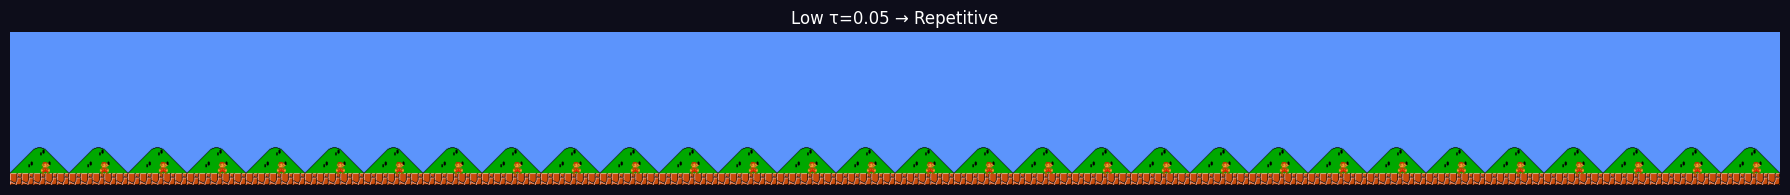

Generating τ=1.0...


/tmp/ipykernel_2546/2109184065.py:36: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


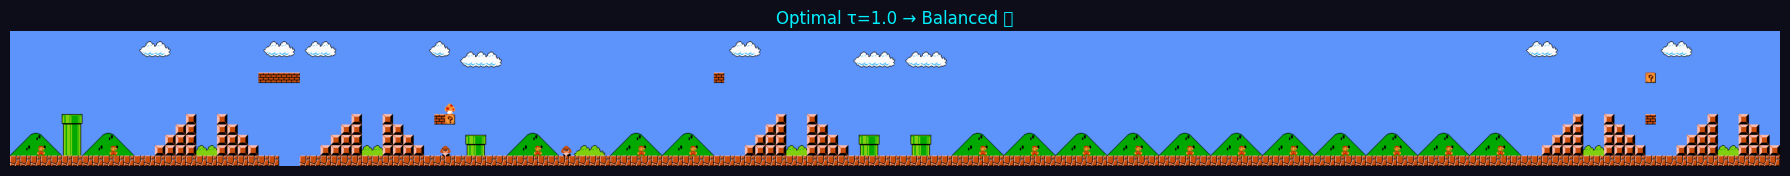

Generating τ=8.0...


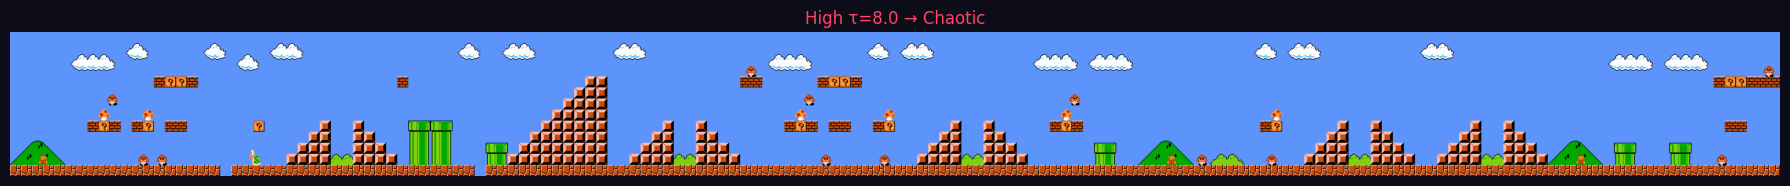

In [ ]:
TEMPS = [
    (0.05, 'Low τ=0.05 → Repetitive'),
    (1.0,  'Optimal τ=1.0 → Balanced ✅'),
    (8.0,  'High τ=8.0 → Chaotic'),
]

for tau, label in TEMPS:
    print(f'Generating τ={tau}...')
    seq = qrc_generate(30, tau=tau)
    show(render(seq, scale=2), label, tau=tau)

## 8. Real Quantum Hardware (IonQ / IBM)

```python
# IonQ
from qiskit_ionq import IonQProvider
provider = IonQProvider(token="YOUR_API_KEY")
backend  = provider.get_backend("ionq_qpu")
compiled = transpile(qc, backend)
counts   = backend.run(compiled, shots=1024).result().get_counts()

# IBM
from qiskit_ibm_runtime import QiskitRuntimeService
service  = QiskitRuntimeService(channel="ibm_quantum", token="YOUR_API_KEY")
backend  = service.least_busy(operational=True, simulator=False)
```

